In [1]:
import pysr
from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
import sys
import os

import numpy as np
import uproot
import awkward as ak

import matplotlib.pyplot as plt
import mplhep as mh
plt.style.use(mh.styles.ROOT)

import torch

from collections import defaultdict

workdir = os.environ.get('WORKDIR')
sys.path.append(workdir)

from src.metrics import classification

In [3]:
run_outputs = f'{workdir}/outputs/metrics'
sr_outputs = f'{workdir}/outputs/sr_runs'
figure_dir = f'{workdir}/figures'

In [4]:
models = ['ParT', 'ResNet', 'ParticleNet']
signals = ['TTBar', 'WToQQ', 'HToGG']

class TestSuite:
    def __init__(self, signal, model_name):

        self.signal = signal
        self.model_name = model_name
        self.surrogate_name = f'{model_name}-S'

        self.outputdir = f'{run_outputs}/{signal}/{model_name}_E3-EVAL_BVAE'
        self.surrogate_folder = f'{sr_outputs}/{signal}/Surrogate/Surrogate_E1-SURROGATES_{model_name}-S_BVAE'
        self.obs_folder = f'{sr_outputs}/{signal}/Observables/Observables_E2-OBSERVABLES_BVAE'

        self.vae_outputs = uproot.open(f'{self.outputdir}/{model_name}_BVAE_outputs.root')
        self.obs_outputs = uproot.open(f'{self.outputdir}/{model_name}_Observables_outputs.root')
        self.dl_outputs = uproot.open(f'{self.outputdir}/{model_name}_{model_name}_outputs.root')
        self.surrogate_outputs = uproot.open(f'{self.outputdir}/{model_name}_{self.surrogate_name}_outputs.root')

In [188]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import r2_score
from scipy.special import softmax

def calculate_roc_metrics(suite, eff=0.5):

    labels = suite.vae_outputs['inputs']['label'].array().to_numpy()
    dl_logits = suite.dl_outputs['preds']['logits'].array().to_numpy()
    dl_logitdiff = dl_logits[:, -1] - dl_logits[:, 0]
    sur_logitdiff = suite.surrogate_outputs['preds']['logit_diff'].array().to_numpy()

    dlfpr, dltpr, dlthresholds = roc_curve(labels, dl_logitdiff)
    surfpr, surtpr, surthresholds = roc_curve(labels, sur_logitdiff)

    dlauc = roc_auc_score(labels, dl_logitdiff)
    surauc = roc_auc_score(labels, sur_logitdiff)

    dl_idx = next(idx for idx, v in enumerate(dltpr) if v>eff)
    dl_rej = 1/dlfpr[dl_idx]

    sur_idx = next(idx for idx, v in enumerate(surtpr) if v>eff)
    sur_rej = 1/surfpr[sur_idx]

    print(f'{suite.model_name} ROC AUC: {dlauc}')
    print(f'{suite.surrogate_name} ROC AUC: {surauc}')
    
    print(f'{suite.model_name} Bkg Rej at {eff*100}% Signal Efficiency: {dl_rej}')
    print(f'{suite.surrogate_name} Bkg Rej at {eff*100}% Signal Efficiency: {sur_rej}')

    r2 = r2_score(dl_logitdiff, sur_logitdiff)
    compression_percentage = (surauc / dlauc) * 100

    print(f'R2 Score: {r2}')
    print(f'Compression Percentage: {compression_percentage}%')

    test_outputs = _model_outputs[suite.signal][suite.model_name]

    test_outputs['dl_auc'] = dlauc
    test_outputs['sur_auc'] = surauc
    test_outputs['dl_rej'] = dl_rej
    test_outputs['sur_rej'] = sur_rej
    test_outputs['r2_score'] = r2
    test_outputs['compression_percentage'] = compression_percentage

In [186]:
_model_outputs = {}

for signal in signals:
    _model_outputs[signal] = {}
    for model_name in models:
        _model_outputs[signal][model_name] = {}

In [189]:
suite = TestSuite('TTBar', 'ParT')

In [190]:
calculate_roc_metrics(suite, eff=0.5)

ParT ROC AUC: 0.9855116926874999
ParT-S ROC AUC: 0.9147035057375
ParT Bkg Rej at 50.0% Signal Efficiency: 285.30670470756064
ParT-S Bkg Rej at 50.0% Signal Efficiency: 13.347570742124933
R2 Score: 0.833149790763855
Compression Percentage: 92.81508403447702%


In [193]:
_model_outputs = {}

for signal in signals:
    _model_outputs[signal] = {}
    for model_name in models:
        _model_outputs[signal][model_name] = {}

for signal in signals:
    print(f'Commencting Testing on Signal: {signal}\n')
    for model_name in models:
        suite = TestSuite(signal, model_name)
        calculate_roc_metrics(suite, eff=0.5)
        print('\n')

Commencting Testing on Signal: TTBar

ParT ROC AUC: 0.9855116926874999
ParT-S ROC AUC: 0.9147035057375
ParT Bkg Rej at 50.0% Signal Efficiency: 285.30670470756064
ParT-S Bkg Rej at 50.0% Signal Efficiency: 13.347570742124933
R2 Score: 0.833149790763855
Compression Percentage: 92.81508403447702%


ResNet ROC AUC: 0.97960461025
ResNet-S ROC AUC: 0.9184012152875001
ResNet Bkg Rej at 50.0% Signal Efficiency: 159.3625498007968
ResNet-S Bkg Rej at 50.0% Signal Efficiency: 14.010507880910684
R2 Score: 0.8713841438293457
Compression Percentage: 93.752234899458%


ParticleNet ROC AUC: 0.9809600472875001
ParticleNet-S ROC AUC: 0.9147034749125
ParticleNet Bkg Rej at 50.0% Signal Efficiency: 149.812734082397
ParticleNet-S Bkg Rej at 50.0% Signal Efficiency: 13.347570742124933
R2 Score: 0.8056182861328125
Compression Percentage: 93.24574200975776%


Commencting Testing on Signal: WToQQ

ParT ROC AUC: 0.9614761866249999
ParT-S ROC AUC: 0.8396378428500001
ParT Bkg Rej at 50.0% Signal Efficiency: 151.

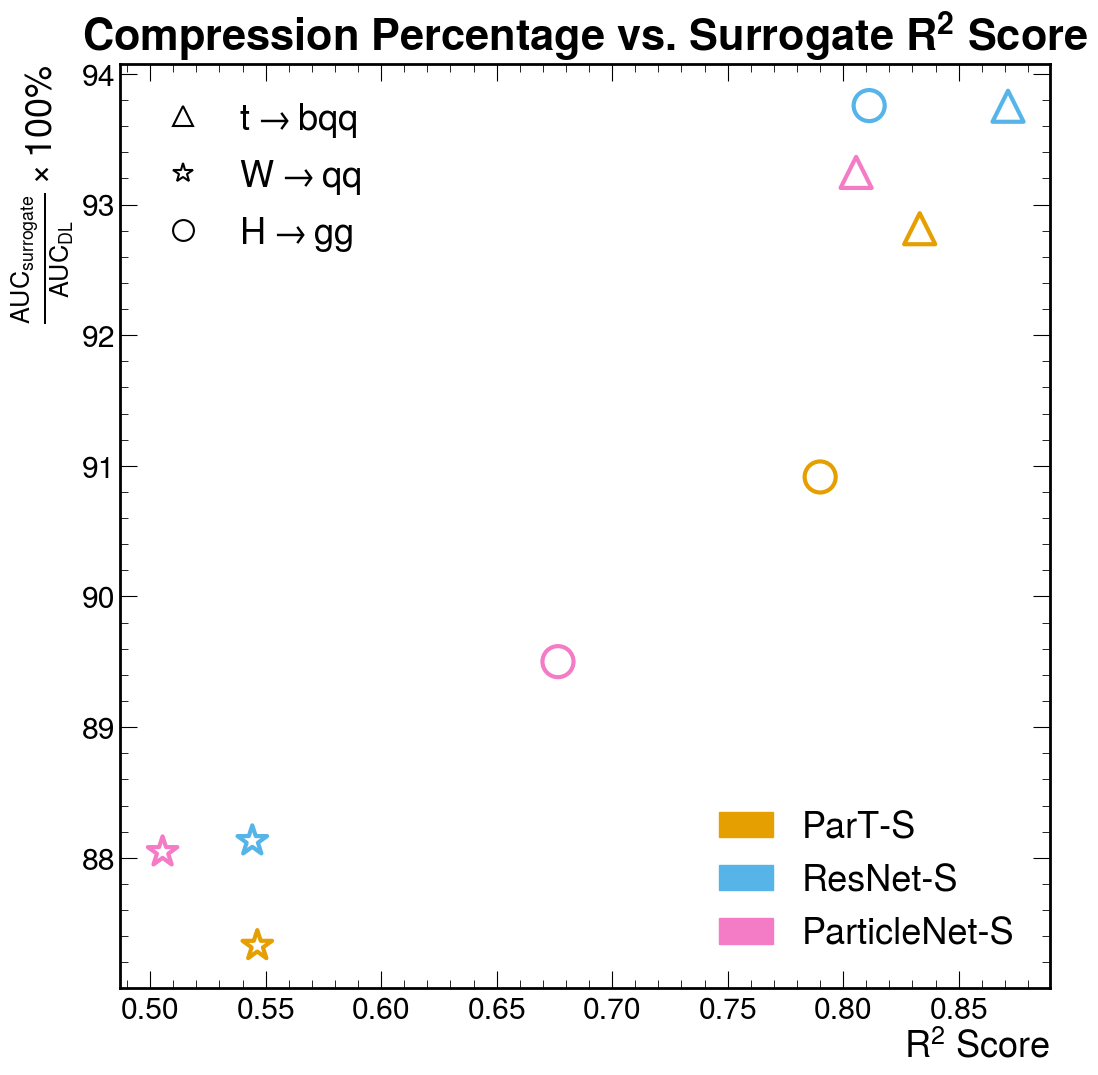

In [221]:
from matplotlib.lines import Line2D
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 12))

signal_markers = {
    r'TTBar': '^',
    r'WToQQ': '*',
    r'HToGG': 'o',
}

model_colors = {
    'ParT-S': '#E69F00',
    'ResNet-S': '#56B4E9',
    'ParticleNet-S': '#f47bc6'
}

custom_markers = [
    Line2D([0], [0], marker='^', markersize=15, color='black', label=r'$t \rightarrow bqq$', linestyle='None', markerfacecolor='none',markeredgewidth=1.5),
    Line2D([0], [0], marker='*', markersize=15, color='black', label=r'$W \rightarrow qq$', linestyle='None', markerfacecolor='none',markeredgewidth=1.5),
    Line2D([0], [0], marker='o', markersize=15, color='black', label=r'$H \rightarrow gg$', linestyle='None', markerfacecolor='none',markeredgewidth=1.5),
]

for signal in signals:
    for model_name in models:
        surrogate_name = f'{model_name}-S'
        comp_pct = _model_outputs[signal][model_name]['compression_percentage']
        r2 = _model_outputs[signal][model_name]['r2_score']
        ax.scatter(
            r2,
            comp_pct,
            s=500,
            facecolors='none',
            linewidths=3,
            marker=signal_markers[signal],
            color=model_colors[surrogate_name]
        )

signals_legend = ax.legend(handles=custom_markers, loc='upper left', prop={'size': 'medium'})
ax.add_artist(signals_legend)

custom_colors = []

for name, color in model_colors.items():
    custom_colors.append(patches.Patch(color=color, label=name))

ax.legend(handles=custom_colors, loc='lower right', prop={'size': 'medium'})

for name, color in model_colors.items():
    custom_colors.append(patches.Patch(color=color, label=name))

ax.set_title(r'Compression Percentage vs. Surrogate $R^2$ Score', fontweight='bold')
ax.set_xlabel(r'$R^2$ Score')
ax.set_ylabel(r'$\frac{AUC_{surrogate}}{AUC_{DL}} \times 100\%$')

fig.savefig(f'{figure_dir}/cpt_vs_r2.pdf', dpi=300, format='pdf')

In [19]:
import umap
import umap.plot

def umap_plot(suite):

    latents = suite.vae_outputs['preds']['mu'].array().to_numpy()
    labels = suite.vae_outputs['inputs']['label'].array().to_numpy()
    shuffled_indices = np.random.permutation(len(latents))

    subset_size = 40000
    shuffled_latents = latents[shuffled_indices][:subset_size]
    shuffled_labels = labels[shuffled_indices][:subset_size]
    
    mapper = umap.UMAP(n_components=2, random_state=42)
        
    mapper.fit(shuffled_latents, verbose=True)
    
    test_outputs = _model_outputs[suite.signal][suite.model_name]
    test_outputs['mapper'] = mapper
    test_outputs['labels'] = shuffled_labels

/home/alang/anaconda3/envs/part_gp/lib/python3.10/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/alang/anaconda3/envs/part_gp/lib/python3.10/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/alang/anaconda3/envs/part_gp/lib/python3.10/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signatur

In [20]:
_model_outputs = {}

for signal in signals:
    _model_outputs[signal] = {}
    for model_name in models:
        _model_outputs[signal][model_name] = {}

for signal in signals:
    print(f'Commencting Testing on Signal: {signal}\n')
    suite = TestSuite(signal, 'ParT')
    umap_plot(suite)
    print('\n')

Commencting Testing on Signal: TTBar



/home/alang/anaconda3/envs/part_gp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(




Commencting Testing on Signal: WToQQ



/home/alang/anaconda3/envs/part_gp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(




Commencting Testing on Signal: HToGG



/home/alang/anaconda3/envs/part_gp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

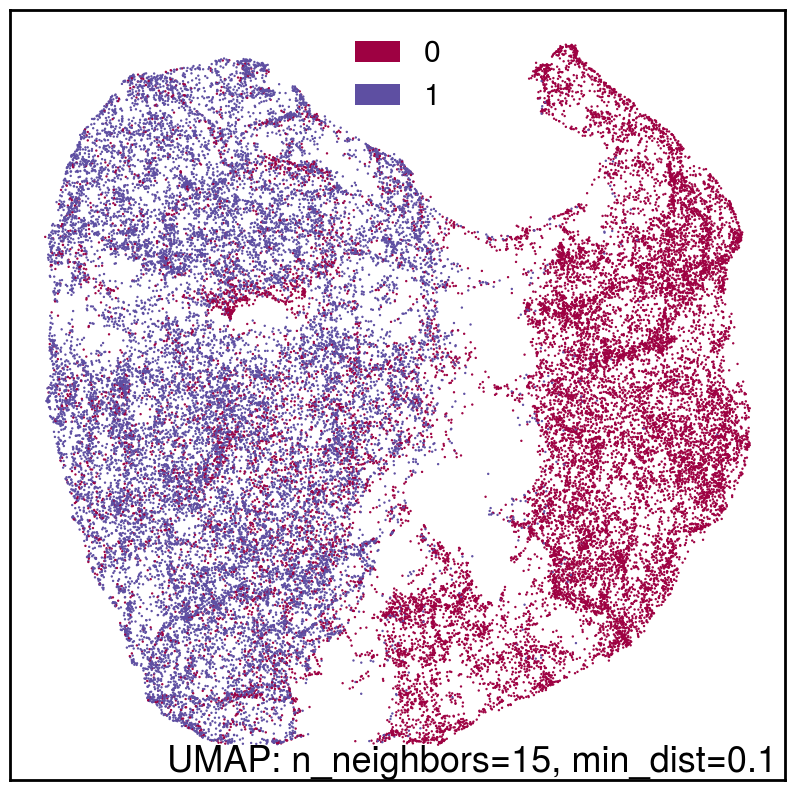

In [10]:
ax = umap.plot.points(mapper, labels=labels, width=1000, height=1000)

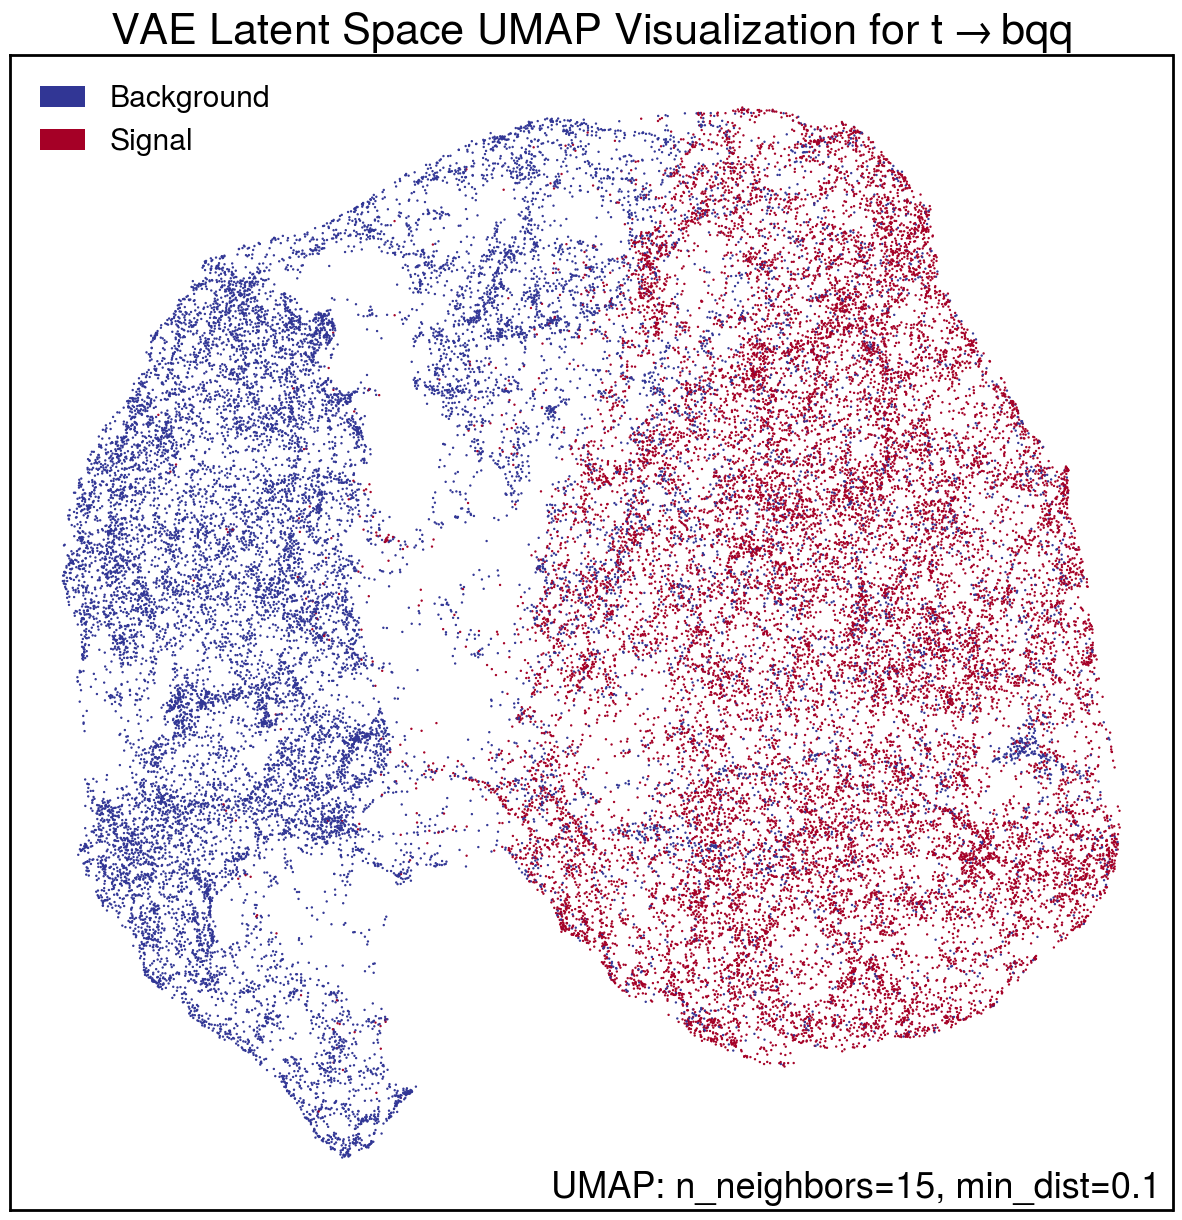

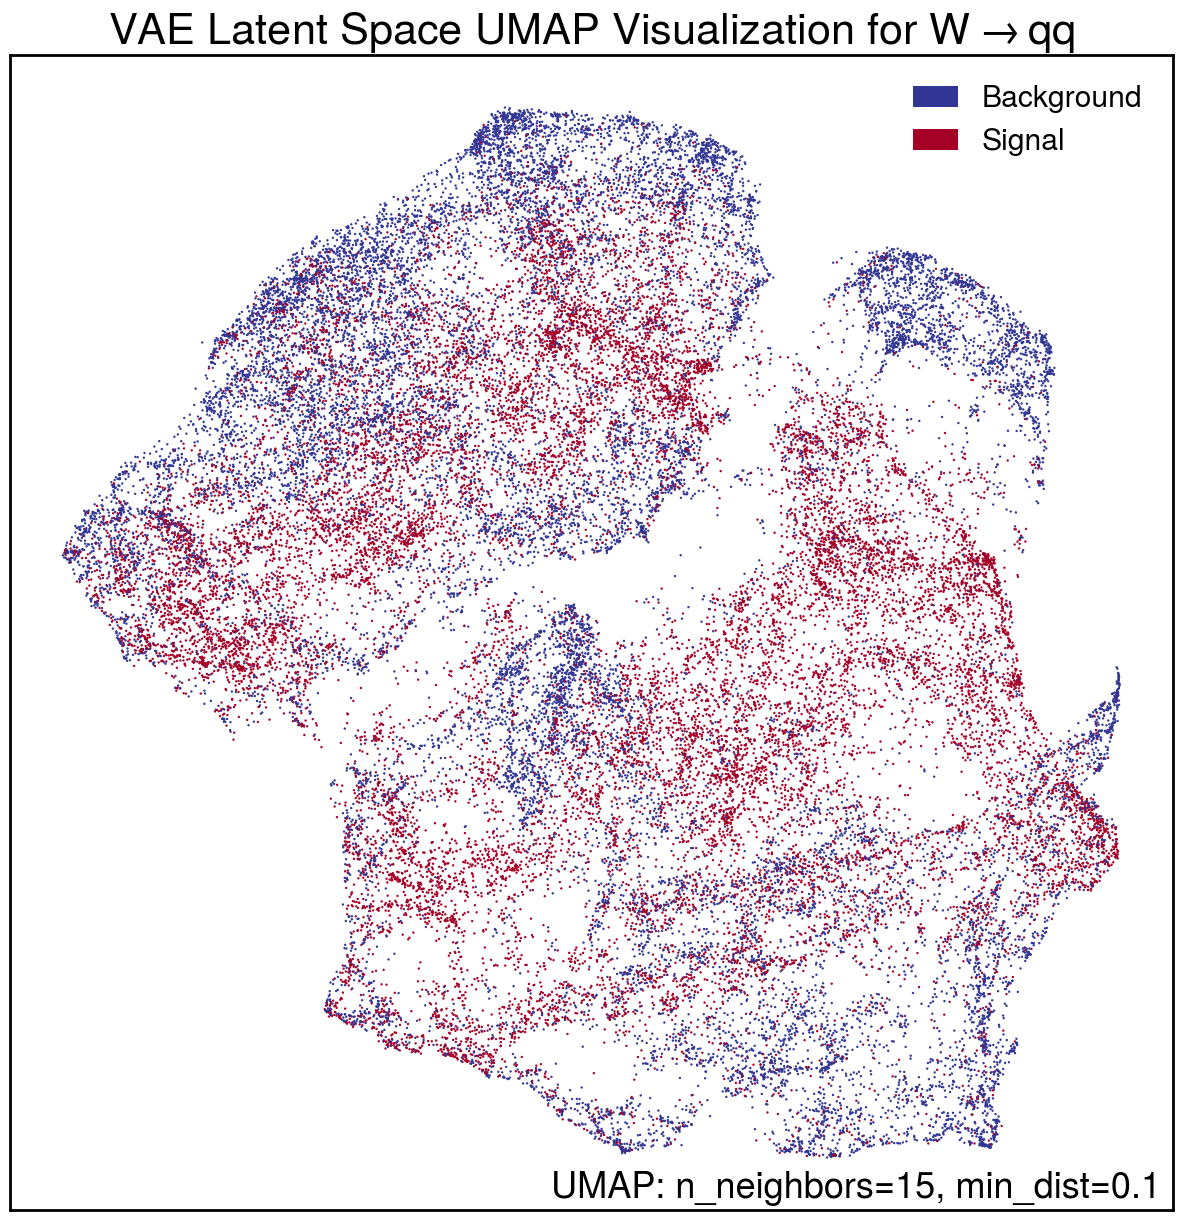

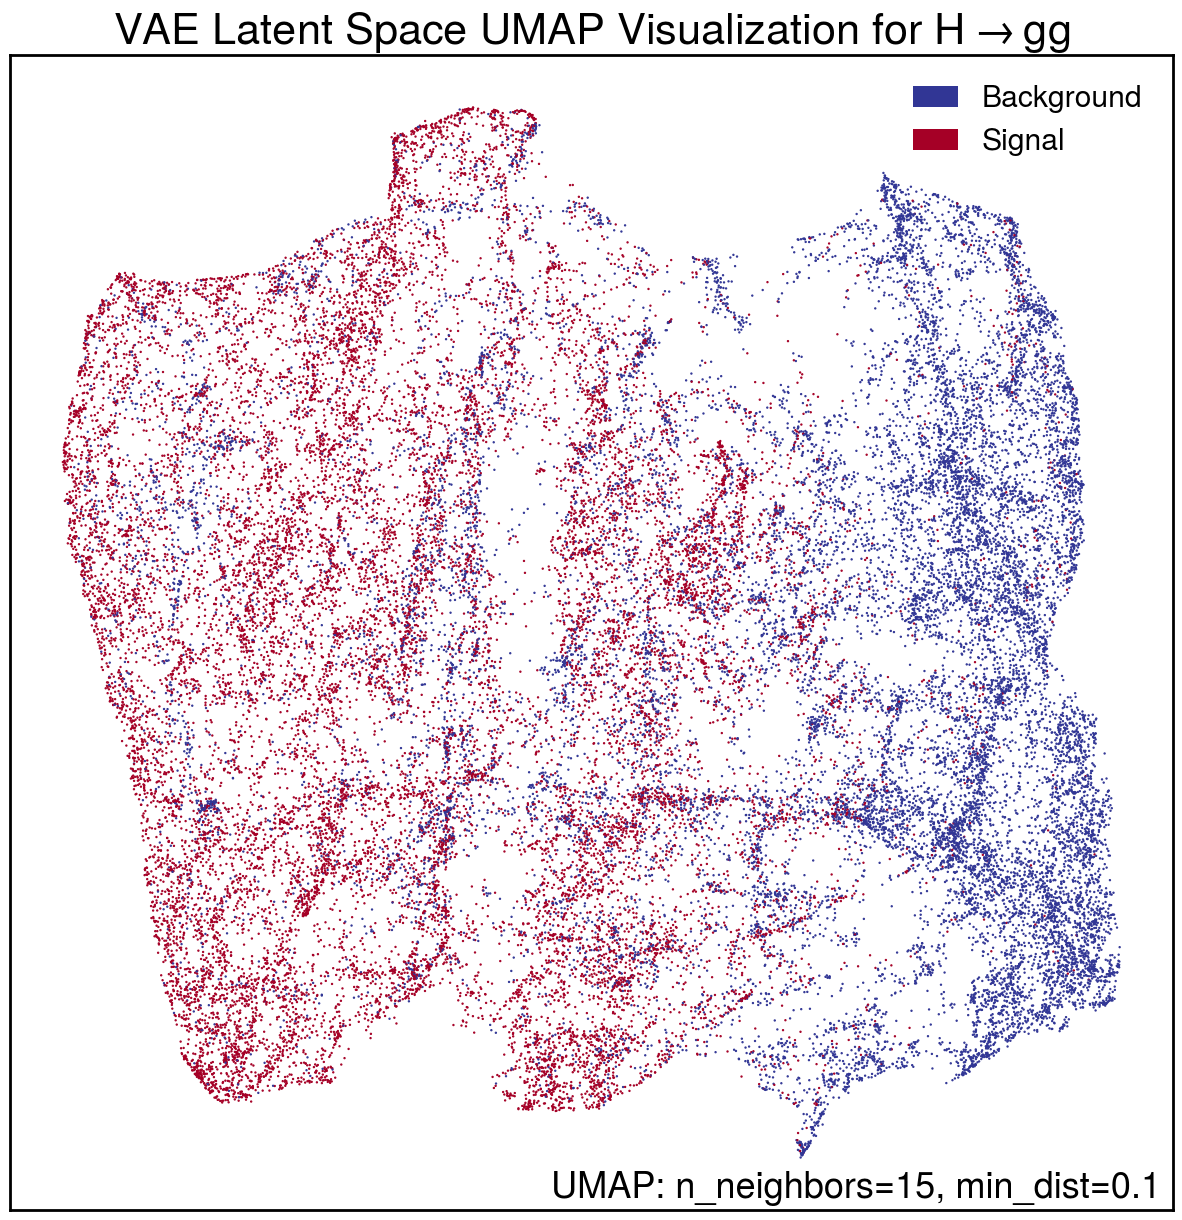

In [23]:
signal_strings = {
    'TTBar': r't \rightarrow bqq',
    'WToQQ': r'W \rightarrow qq',
    'HToGG': r'H \rightarrow gg'
}

for signal in signals:
    signal_mapper = _model_outputs[signal]['ParT']['mapper']
    sig_labels = _model_outputs[signal]['ParT']['labels']
    sig_bkg = np.array(['Background', 'Signal'])

    ax = umap.plot.points(
        signal_mapper, 
        labels=sig_bkg[sig_labels], 
        width=1500, 
        height=1500,
        color_key_cmap='RdYlBu_r'
    )

    ax.set_rasterized(True)

    ax.set_title(rf'VAE Latent Space UMAP Visualization for ${signal_strings[signal]}$')
    plt.show()

    ax.get_figure().savefig(f'{figure_dir}/umap_vae_{signal}.pdf', dpi=150, format='pdf')

In [17]:
import sympy as sp

_model_outputs = {}
for signal in signals:
    _model_outputs[signal] = {}
    for model_name in models:
        _model_outputs[signal][model_name] = {}

for signal in signals:
    for model_name in models:
        suite = TestSuite(signal, model_name)
        regressor = PySRRegressor.from_file(run_directory = suite.surrogate_folder)

        total_counts = []

        for i in range(8):
            symbol = sp.Symbol(f'x{i}')

            counts_array = regressor.equations_['sympy_format'].apply(lambda expr: expr.count(symbol)).tolist()
            total_counts.append(sum(counts_array))

        _model_outputs[signal][model_name]['counts'] = total_counts

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Surrogate/Surrogate_E1-SURROGATES_ParT-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Surrogate/Surrogate_E1-SURROGATES_ResNet-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Surrogate/Surrogate_E1-SURROGATES_ParticleNet-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ParT-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ResNet-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ParticleNet-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/HToGG/Surrogate/Surrogate_E1-SURROGATES_ParT

In [19]:
for signal in signals:

    signal_counts = []
    
    for model_name in models:
        counts = _model_outputs[signal][model_name]['counts']
        signal_counts.append(np.array(counts))

    result = np.sum(signal_counts, axis=0)
    print(result)

[  7  61  43   0 107   0  43  65]
[ 12   8 102 150  41  12   0 153]
[ 75  13   2   2   0  97  73 130]


In [22]:
_model_outputs = {}
for signal in signals:
    _model_outputs[signal] = {}
    for model_name in models:
        _model_outputs[signal][model_name] = {}

for signal in signals:
    print(f'Working on {signal}')
    for model_name in models:
        suite = TestSuite(signal, model_name)
        regressor = PySRRegressor.from_file(run_directory = suite.surrogate_folder)

        print(f'LaTeX equation for {model_name}')
        print(regressor.latex())
        print('\r')

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Surrogate/Surrogate_E1-SURROGATES_ParT-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Surrogate/Surrogate_E1-SURROGATES_ResNet-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Surrogate/Surrogate_E1-SURROGATES_ParticleNet-S_BVAE/checkpoint.pkl...


Working on TTBar
LaTeX equation for ParT
\left(- x_{4} - 0.331\right) 9.51

LaTeX equation for ResNet
\frac{{1.93}^{x_{8}} + x_{4}}{-0.113}

LaTeX equation for ParticleNet
x_{4} \left(-8.07\right) - 2.56

Working on WToQQ


Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ParT-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ResNet-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ParticleNet-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/HToGG/Surrogate/Surrogate_E1-SURROGATES_ParT-S_BVAE/checkpoint.pkl...


LaTeX equation for ParT
\frac{x_{7} \left(x_{15} - \left(- x_{2} + x_{3}\right)\right)}{0.319}

LaTeX equation for ResNet
\frac{x_{7} \left(x_{15} + x_{2} - x_{3}\right)}{0.353}

LaTeX equation for ParticleNet
\tanh{\left(x_{7} \left(x_{2} - x_{3} - 0.690\right) \right)} 5.59

Working on HToGG


Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/HToGG/Surrogate/Surrogate_E1-SURROGATES_ResNet-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/HToGG/Surrogate/Surrogate_E1-SURROGATES_ParticleNet-S_BVAE/checkpoint.pkl...


LaTeX equation for ParT
- x_{6} + \left(x_{15} - x_{7} - -1.61\right) \left(-5.14\right)

LaTeX equation for ResNet
\left(x_{5} + 2.48\right) \left(- x_{13} - x_{15} - x_{6} + x_{7} - 3.24\right)

LaTeX equation for ParticleNet
- 5.48 \left(x_{15} - x_{7} + 1.51\right)



In [5]:
from torch.func import vmap, grad
from matplotlib.collections import LineCollection

class EquationVisualizer:
    def __init__(self, model, inputs: torch.Tensor, labels: torch.Tensor):
        '''
        Create visualizations for SymPy symbolic expressions based on the diff between logits
        '''

        self.model = model
        self.inputs = inputs

        self.params = {k: v.detach() for k, v in model.named_parameters()}
        self.buffers = {k: v.detach() for k, v in model.named_buffers()}

        bkg_indices = np.where(labels == 0)[0]
        sig_indices = np.where(labels == 1)[0]
        self.sig_inputs = self.inputs[sig_indices]
        self.bkg_inputs = self.inputs[bkg_indices]

        self.data_points = defaultdict(lambda: {
            category: defaultdict(list) 
            for category in ["bkg", "sig", "none"]
        })

    def ice(self, idx, segments, order, event=None, method='subsample', qty=None):
        if event == 'sig':
            input_tensor = self.sig_inputs
        elif event == 'bkg':
            input_tensor = self.bkg_inputs
        elif event == 'none':
            input_tensor = self.inputs
        else:
            print('Need Valid Event!')
            return

        max_val = torch.max(input_tensor[idx])
        min_val = torch.min(input_tensor[idx])

        for val in torch.linspace(min_val, max_val, segments):
            input_tensor.requires_grad_(False)
            input_tensor[:, idx] = val
            input_tensor.requires_grad_()

            model_output = self.model(input_tensor)
            logit_diff = model_output

            for _ in range(order):
                #logit_diff = torch.autograd.grad(logit_diff, input_tensor, create_graph=True, retain_graph=True)[0][0][:, idx]
                ft_compute_sample_grad = vmap(grad(self.model), in_dims=(None, None, 0, 0))
                logit_diff = ft_compute_sample_grad(input_tensor)

            self.data_points[f'dim_{idx}_order_{order}'][event]['x'].append(val.item())
            self.data_points[f'dim_{idx}_order_{order}'][event]['y'].append(logit_diff.detach().cpu().numpy())

        return self.data_points

def plot_ice(x, y, model_name, signal, dim, eq, var):
    signal_lookup = {
        'TTBar': r'$t\rightarrow bqq$',
        'WToQQ': r'$W\rightarrow qq$',
        'HToGG': r'$H\rightarrow gg$'
    }

    var_lookup = {
        'lnvar': r'\ln \sigma^2',
        'mu': r'\mu'
    }
    
    signal_str = signal_lookup[signal]
    fig_prefix = f'{figure_dir}/{signal}/{model_name}/{model_name}'
    dirname = os.path.dirname(fig_prefix)
    if dirname and not os.path.exists(dirname):
        os.makedirs(dirname)

    y_vals = y.T
    centered_lines = y_vals - np.expand_dims(y_vals[:, 0], axis=1)

    x_2d = np.tile(x, (centered_lines.shape[0], 1))
    segments = np.stack([x_2d, centered_lines], axis=-1)
    
    pdp_line = np.mean(y, axis=1)
    pdp_line_centered = np.mean(centered_lines.T, axis=1)
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    line_segments = LineCollection(segments, colors='k', alpha=0.0001)
    ax.add_collection(line_segments, rasterized=True)
    
    ax.plot(x, pdp_line_centered, color='r', label='PDP')
    ax.set_title(rf'ICE Plot: Centered Logit Difference vs. ${var_lookup[var]}_{{{dim}}}$')
    ax.set_xlabel(rf'${var_lookup[var]}_{{{dim}}}$')
    ax.set_ylabel(rf'$\Delta f_{{sig-bkg}}({var_lookup[var]}_{{{dim}}}) - \Delta f_{{sig-bkg}}(\min({var_lookup[var]}_{{{dim}}}))$')
    ax.margins(y=0.2)
    
    ax.text(0.05, 0.96, s=f'Model: {model_name}', fontweight='bold', fontsize='large', transform=ax.transAxes, va='top', ha='left')
    ax.text(0.05, 0.91, s=signal_str, transform=ax.transAxes, va='top', ha='left')
    
    ax.legend()
    plt.show()
    fig.savefig(f'{fig_prefix}_ICEPDP_{var}_{dim}.pdf', dpi=150, format='pdf')
    plt.close(fig)

Working on TTBar


Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Surrogate/Surrogate_E1-SURROGATES_ParT-S_BVAE/checkpoint.pkl...


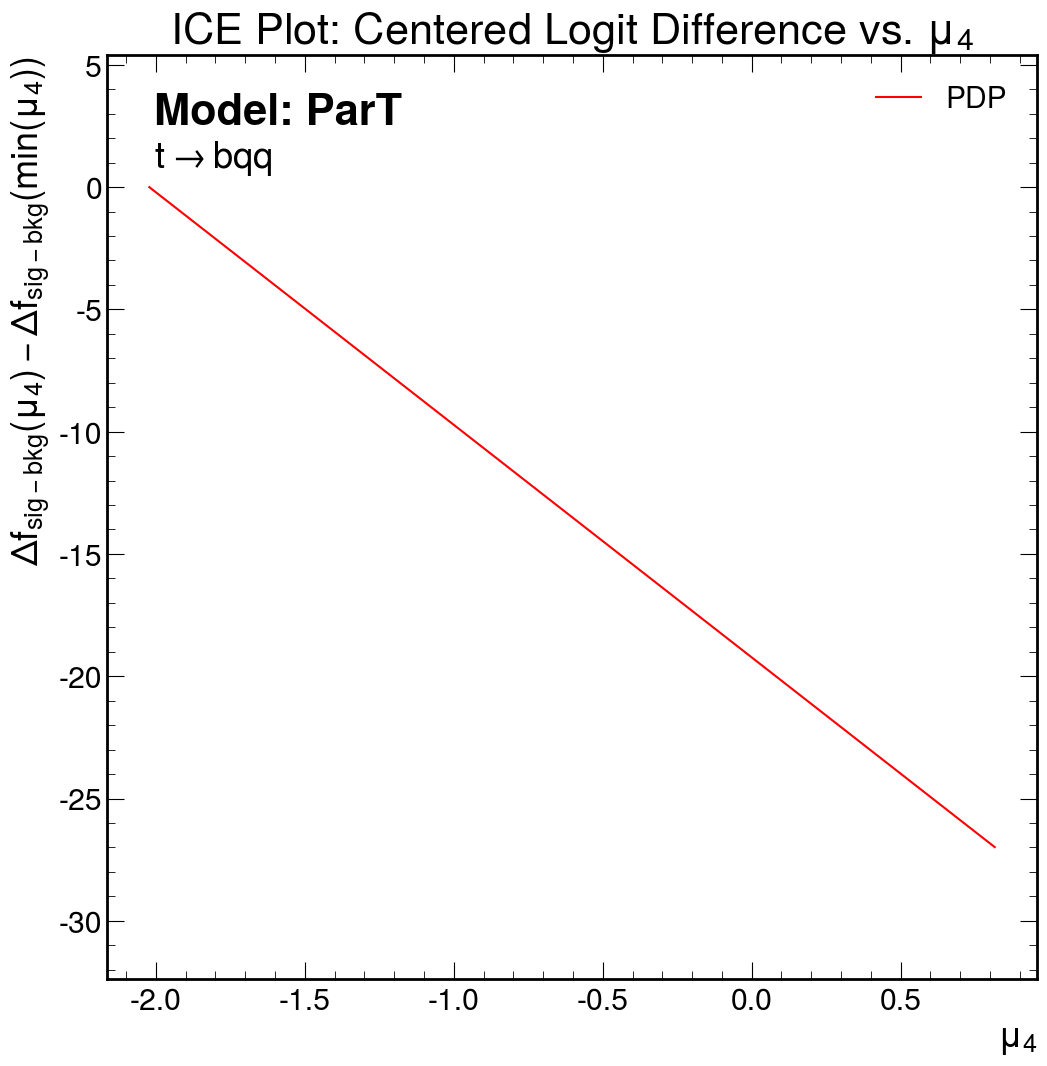

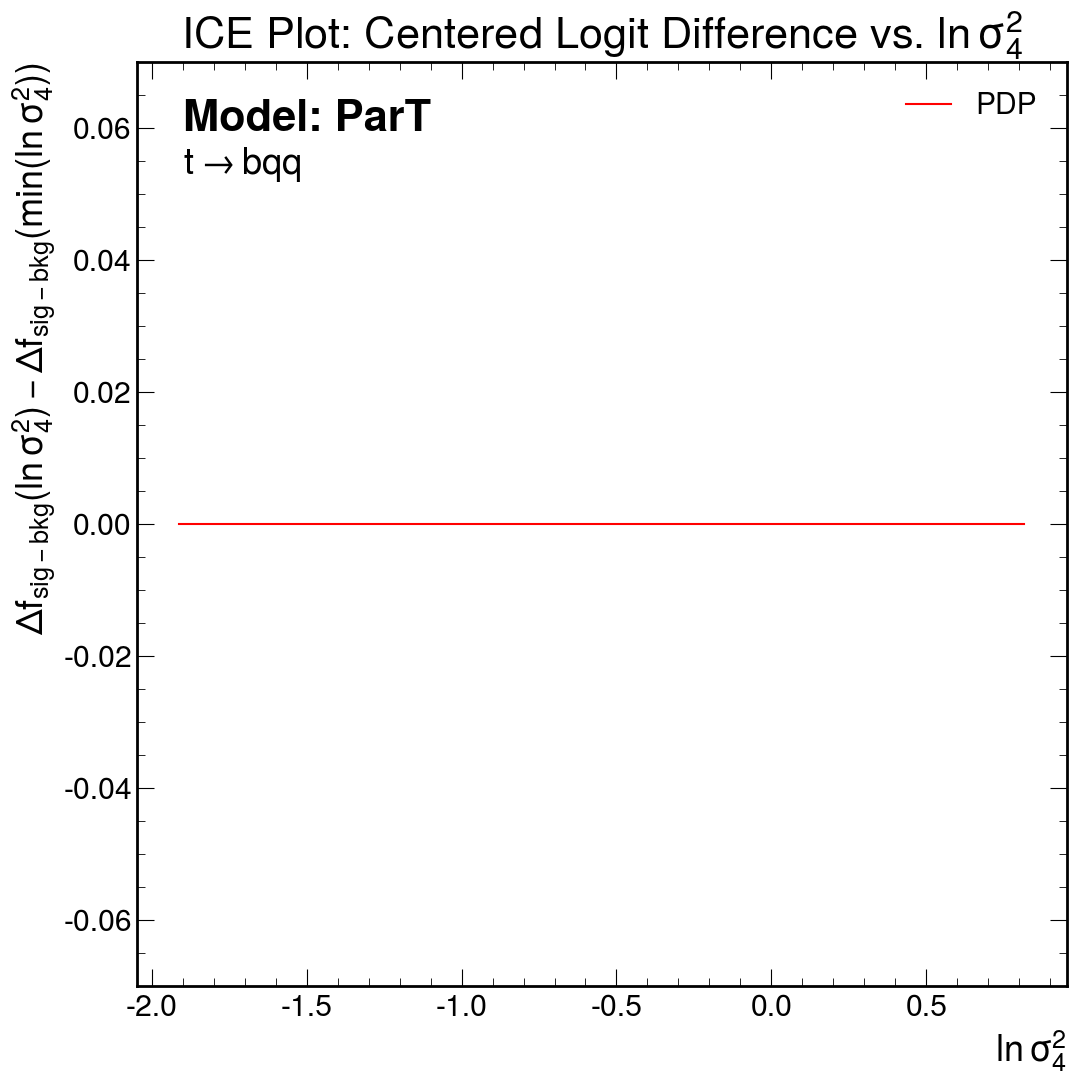

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Surrogate/Surrogate_E1-SURROGATES_ResNet-S_BVAE/checkpoint.pkl...


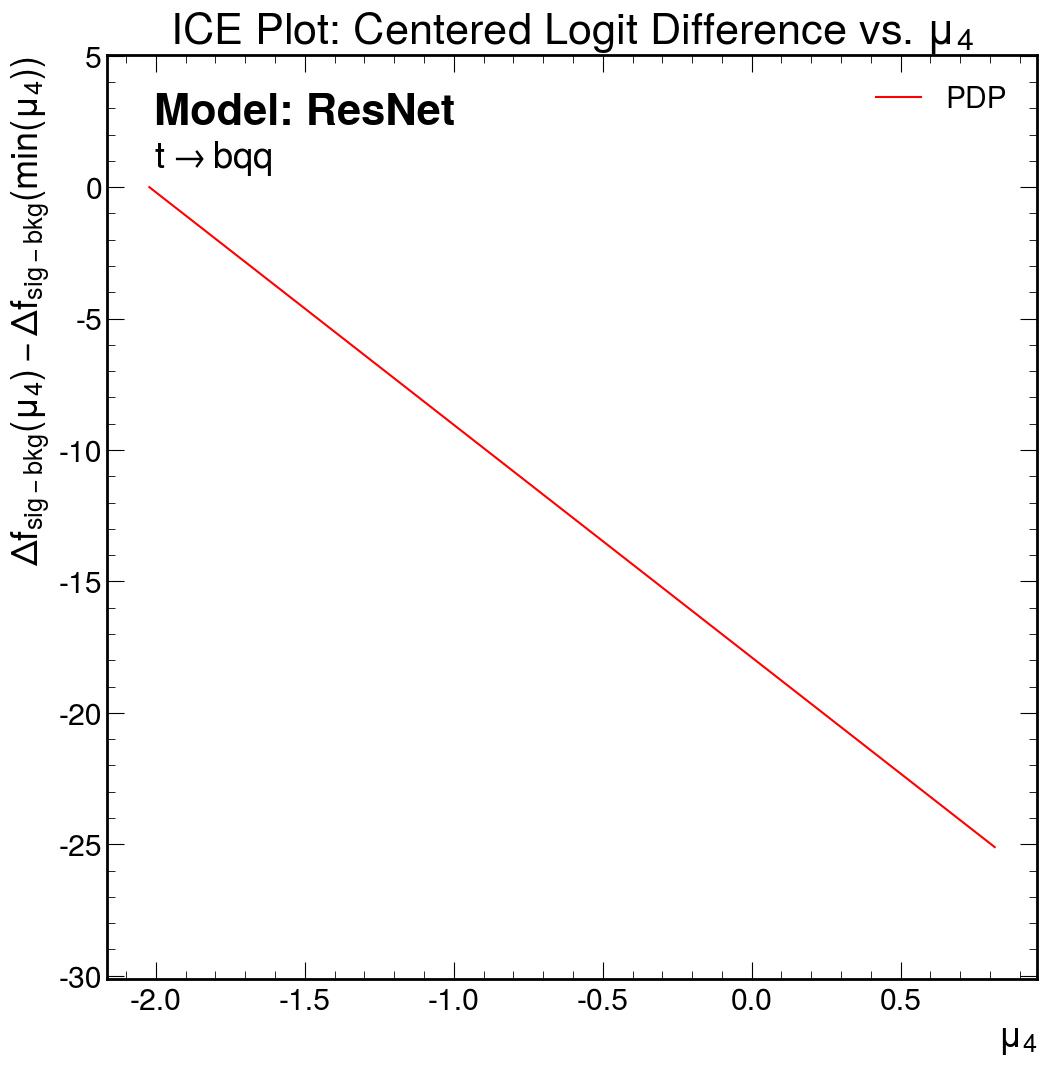

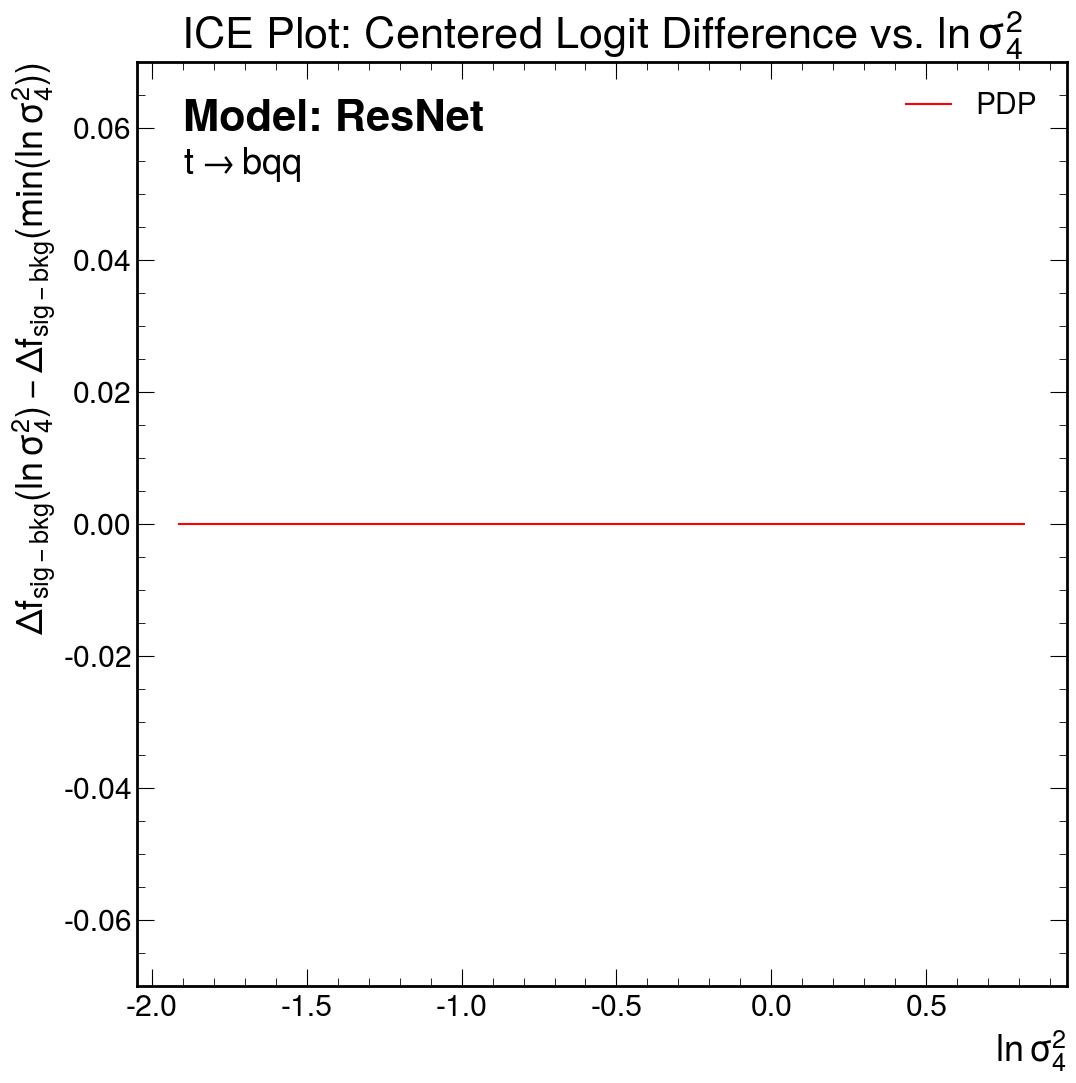

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Surrogate/Surrogate_E1-SURROGATES_ParticleNet-S_BVAE/checkpoint.pkl...


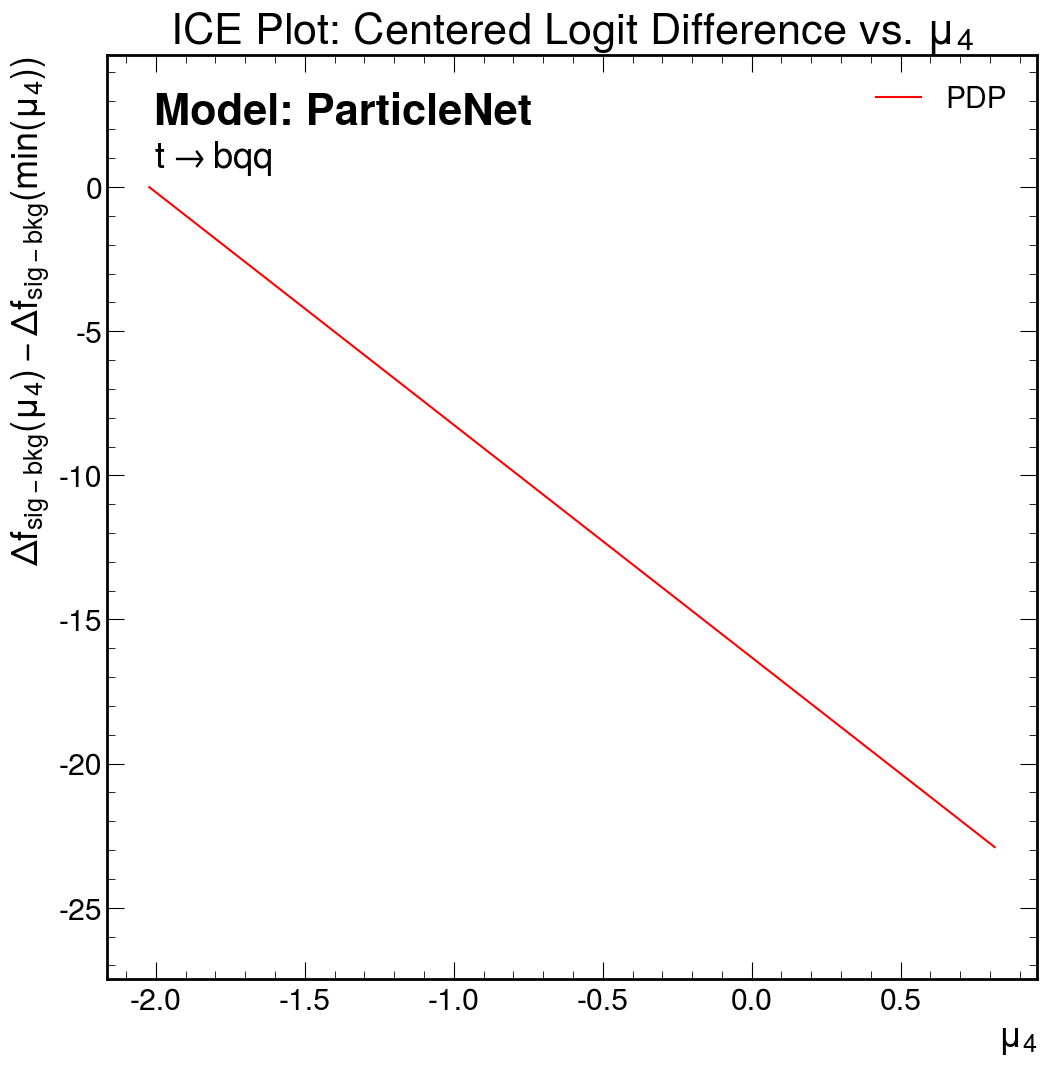

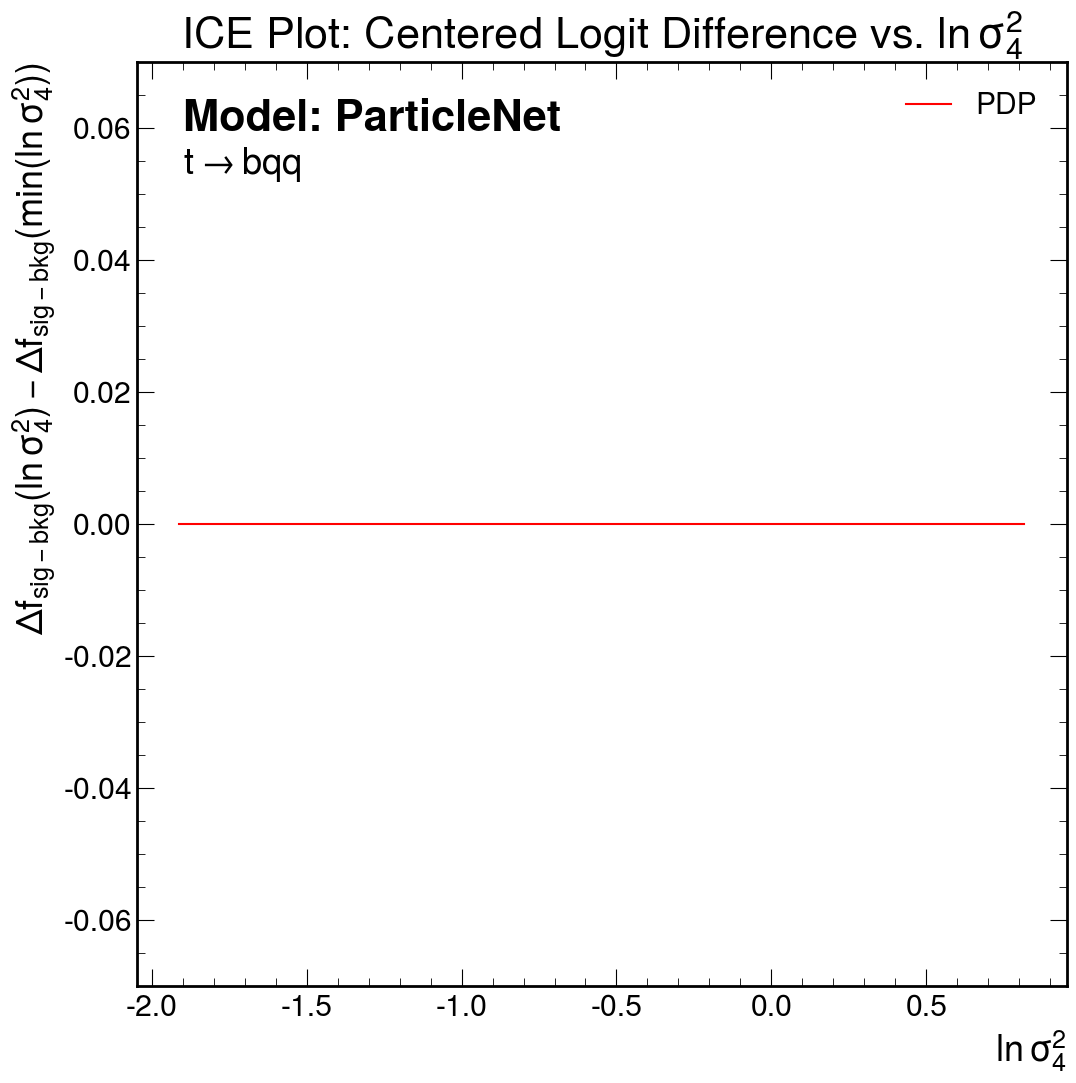

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ParT-S_BVAE/checkpoint.pkl...


Working on WToQQ


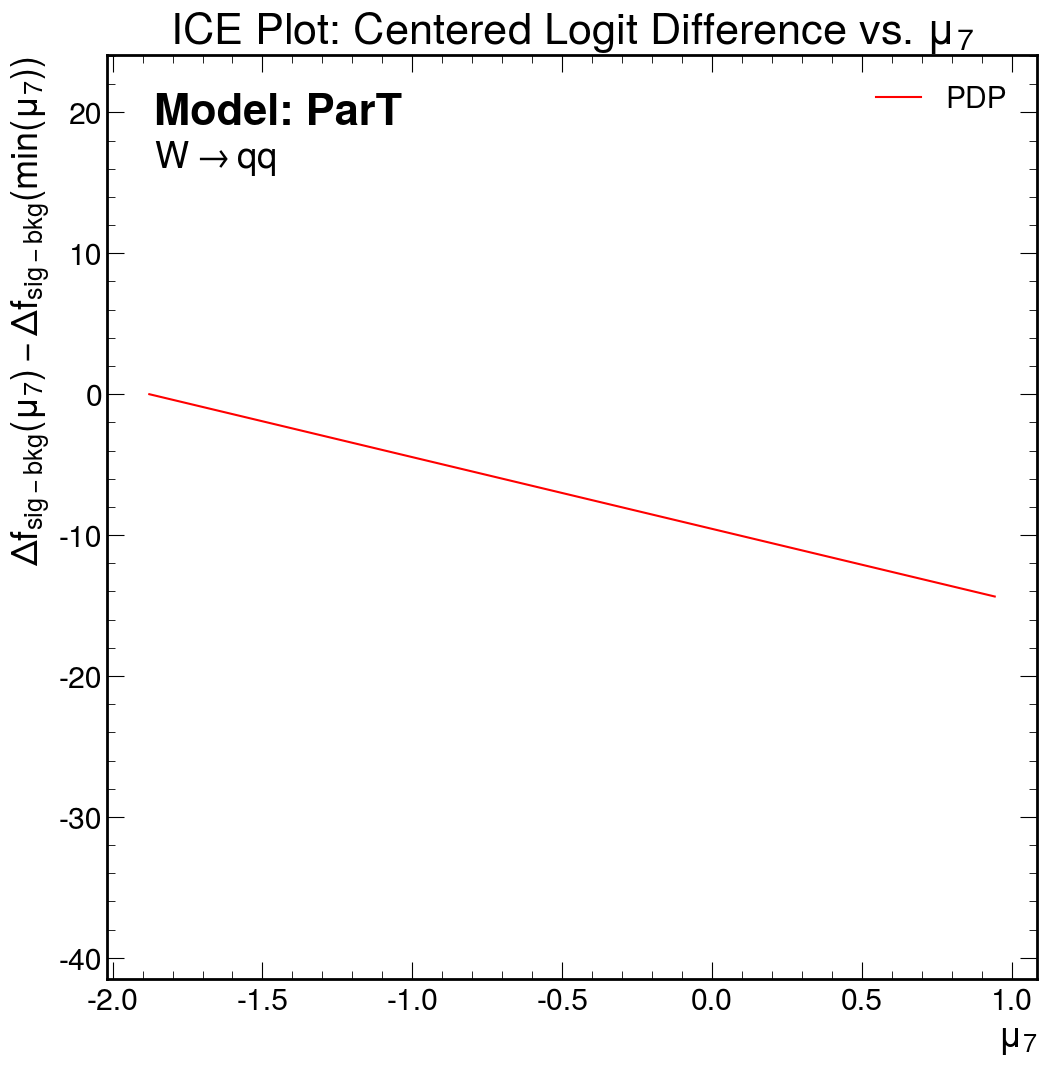

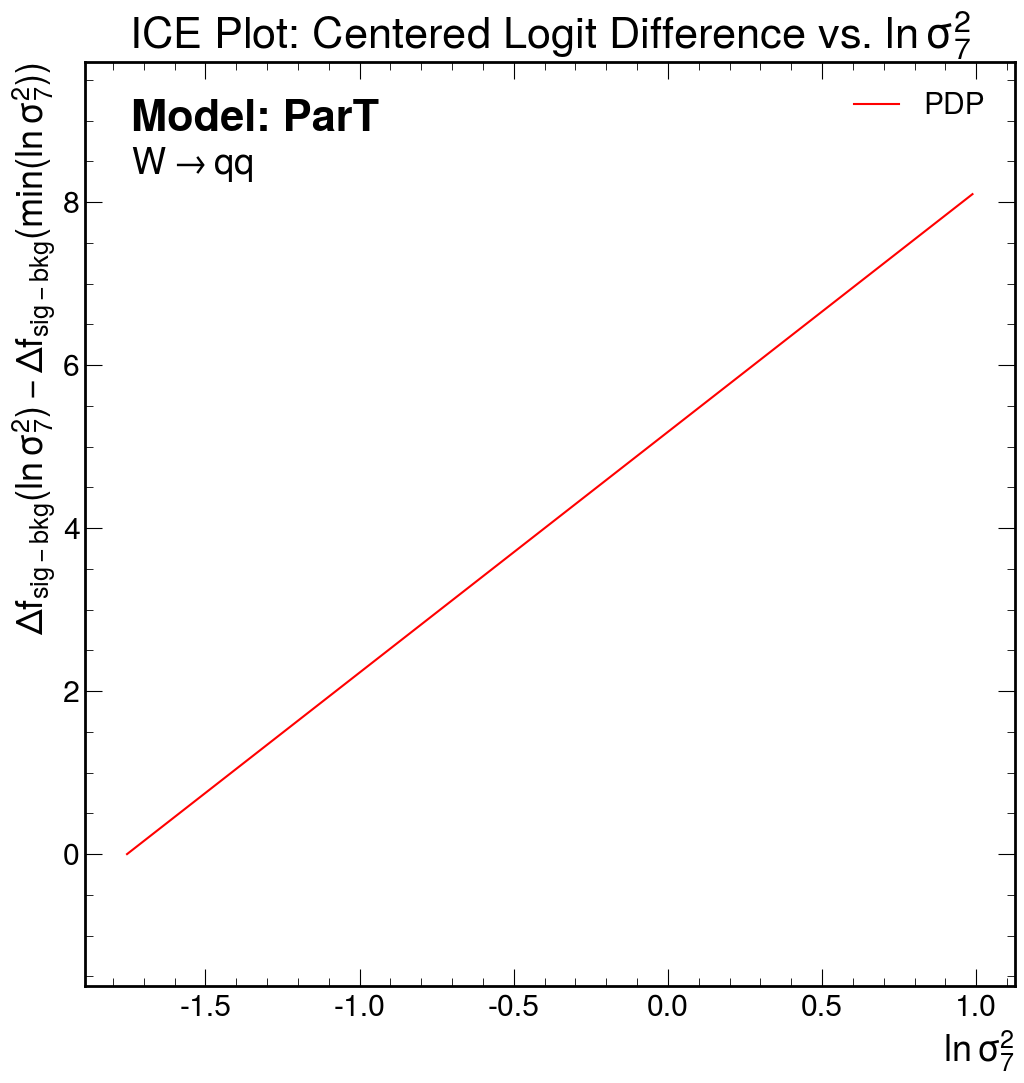

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ResNet-S_BVAE/checkpoint.pkl...


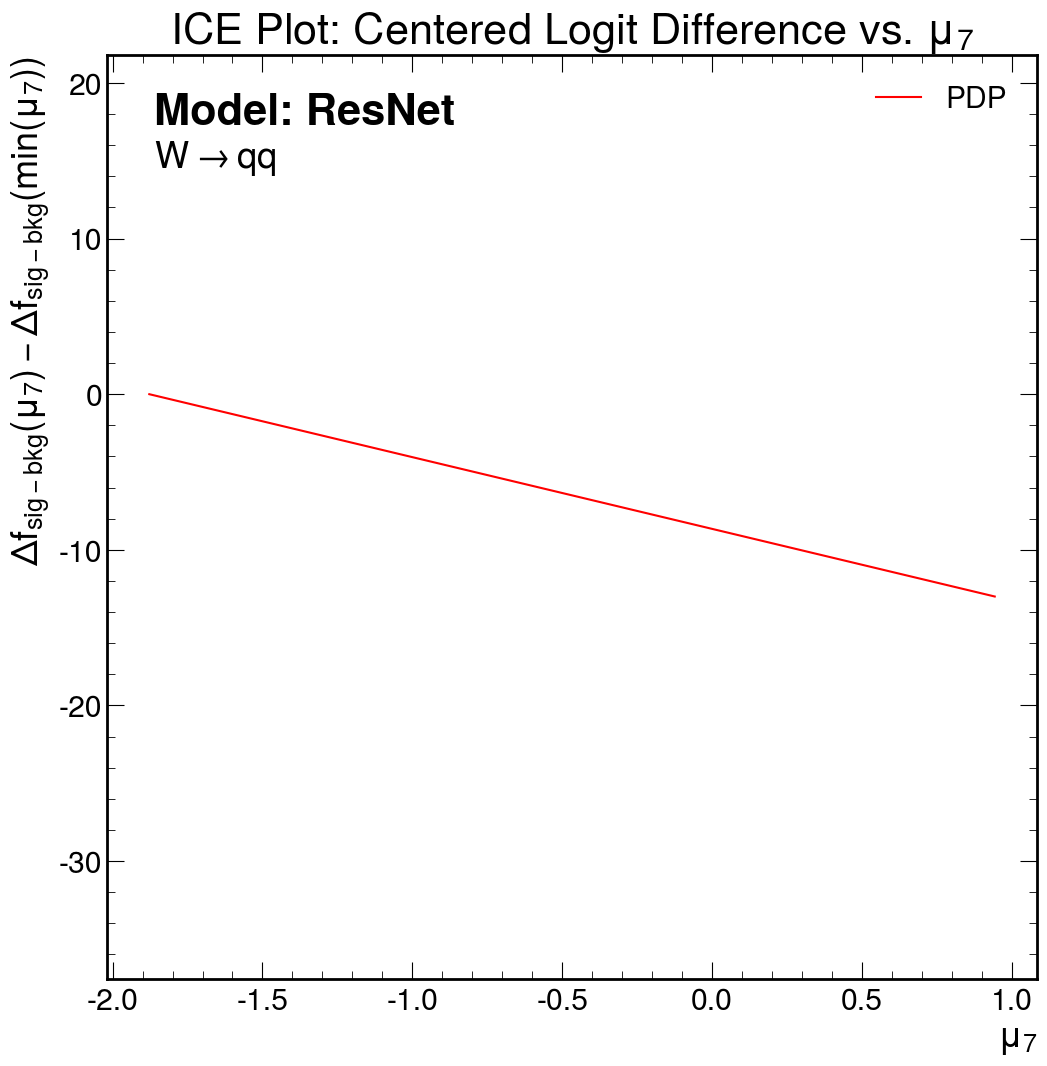

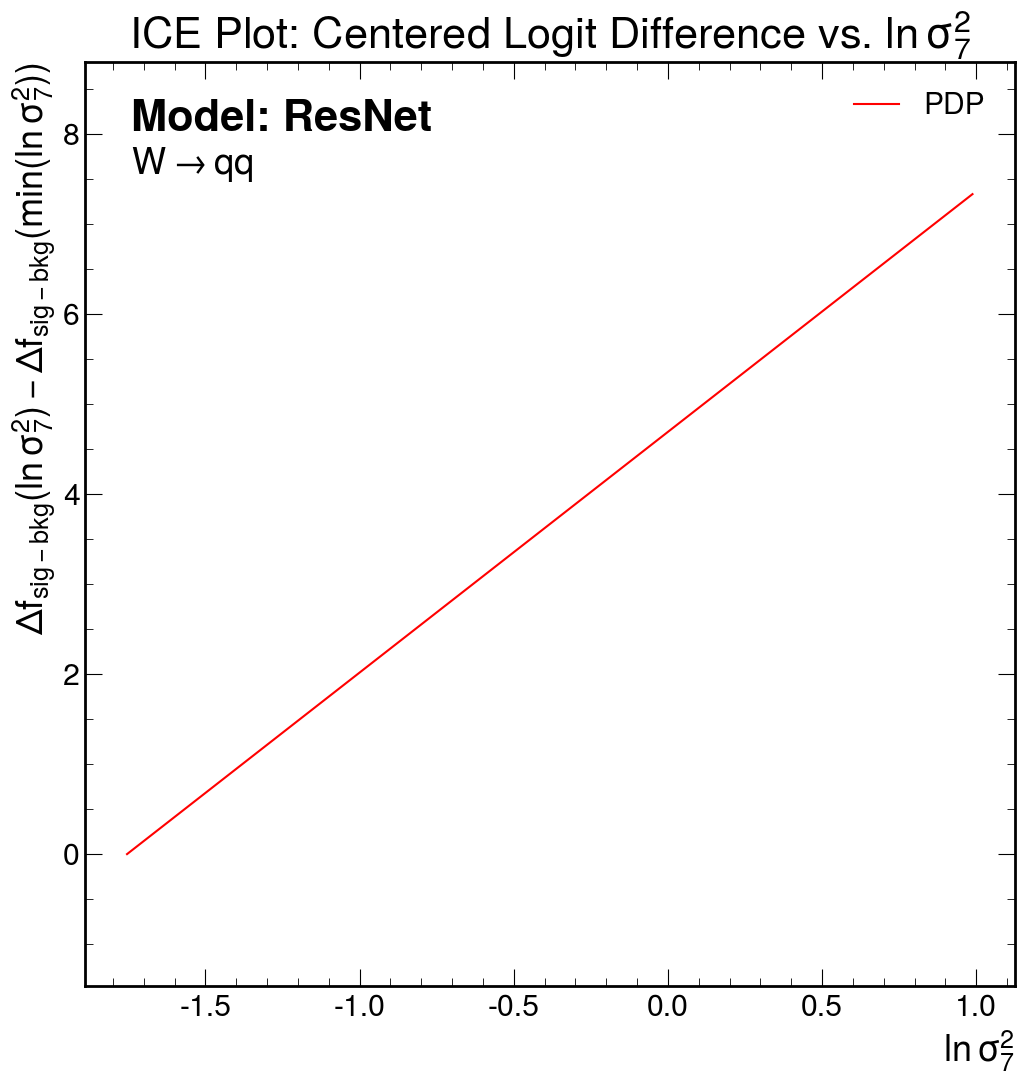

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ParticleNet-S_BVAE/checkpoint.pkl...


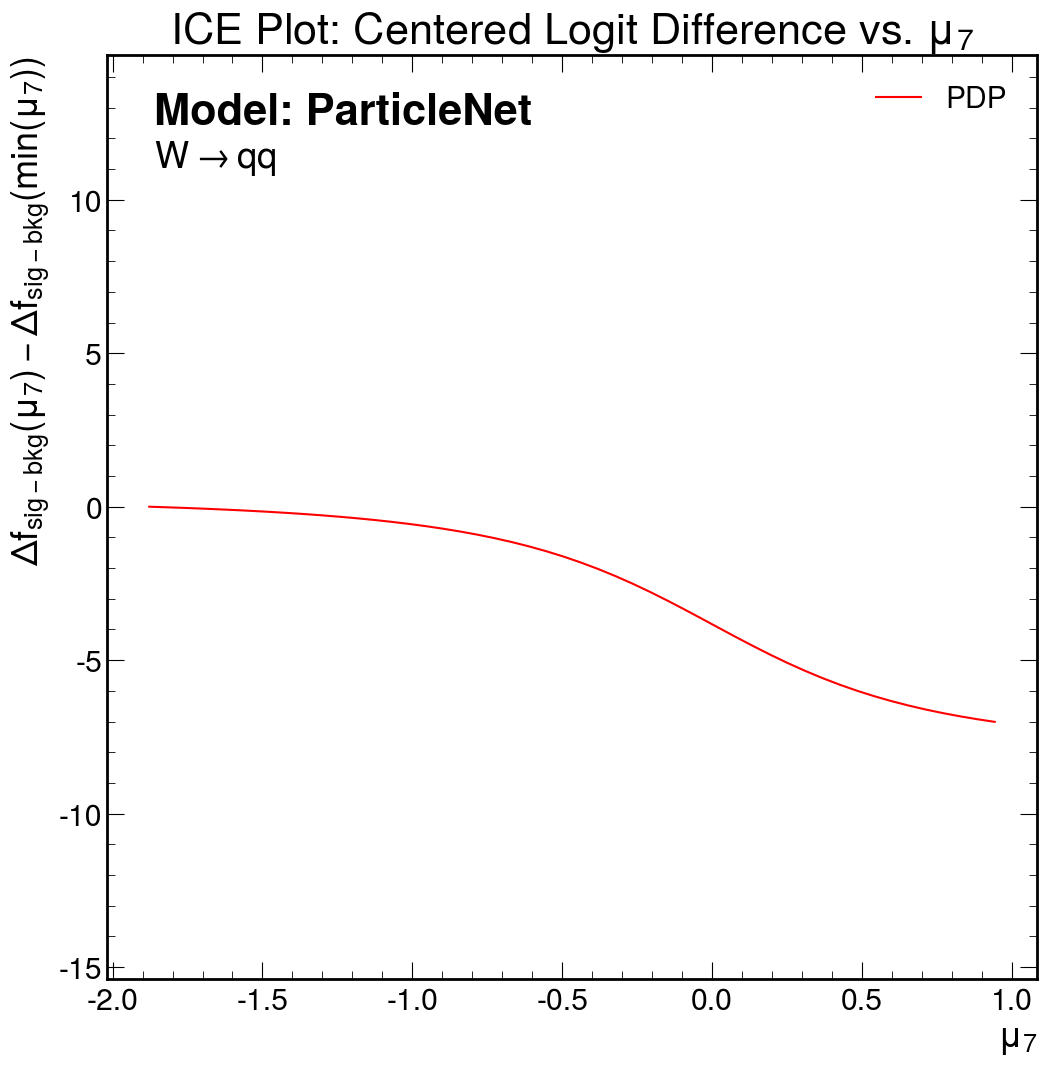

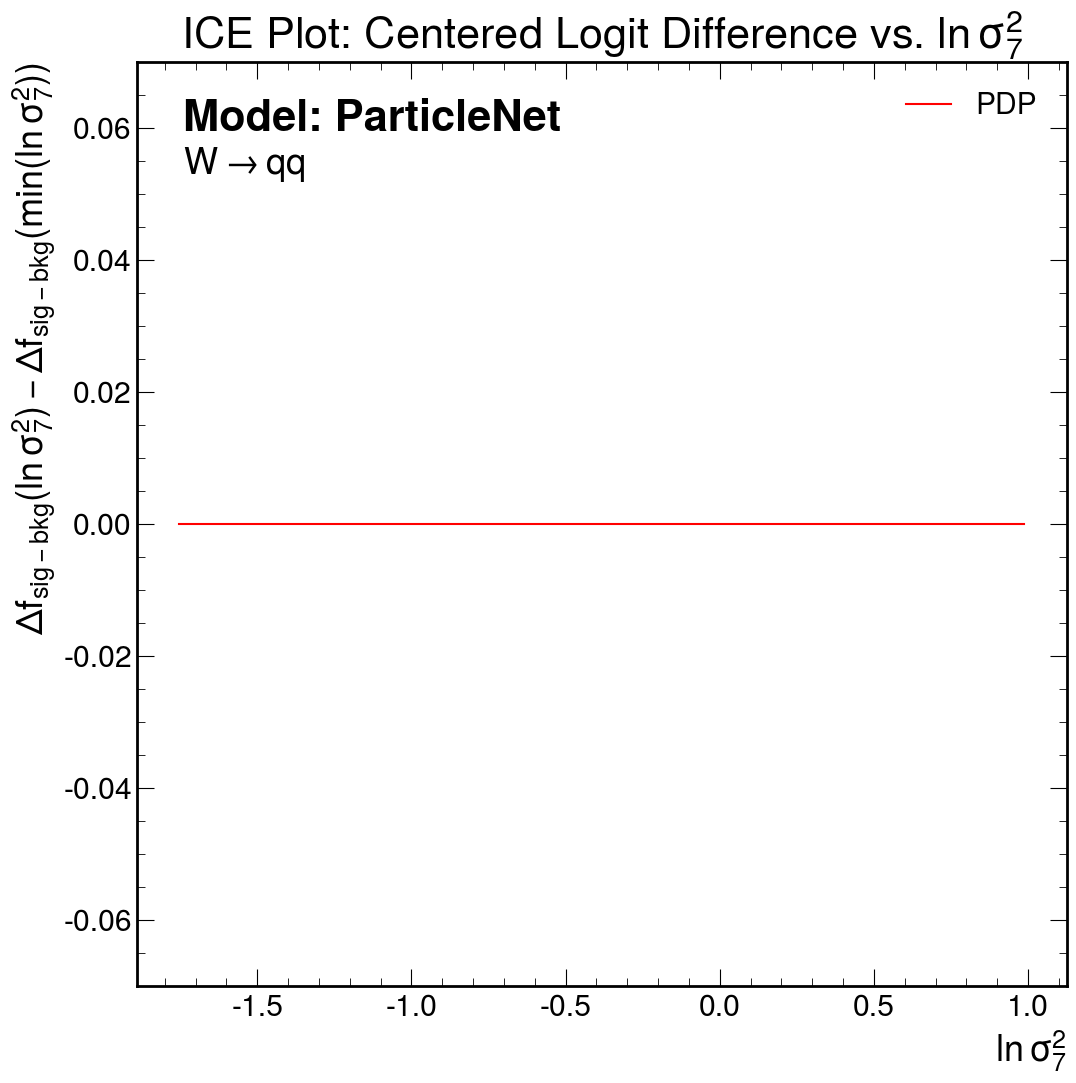

Working on HToGG


Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/HToGG/Surrogate/Surrogate_E1-SURROGATES_ParT-S_BVAE/checkpoint.pkl...


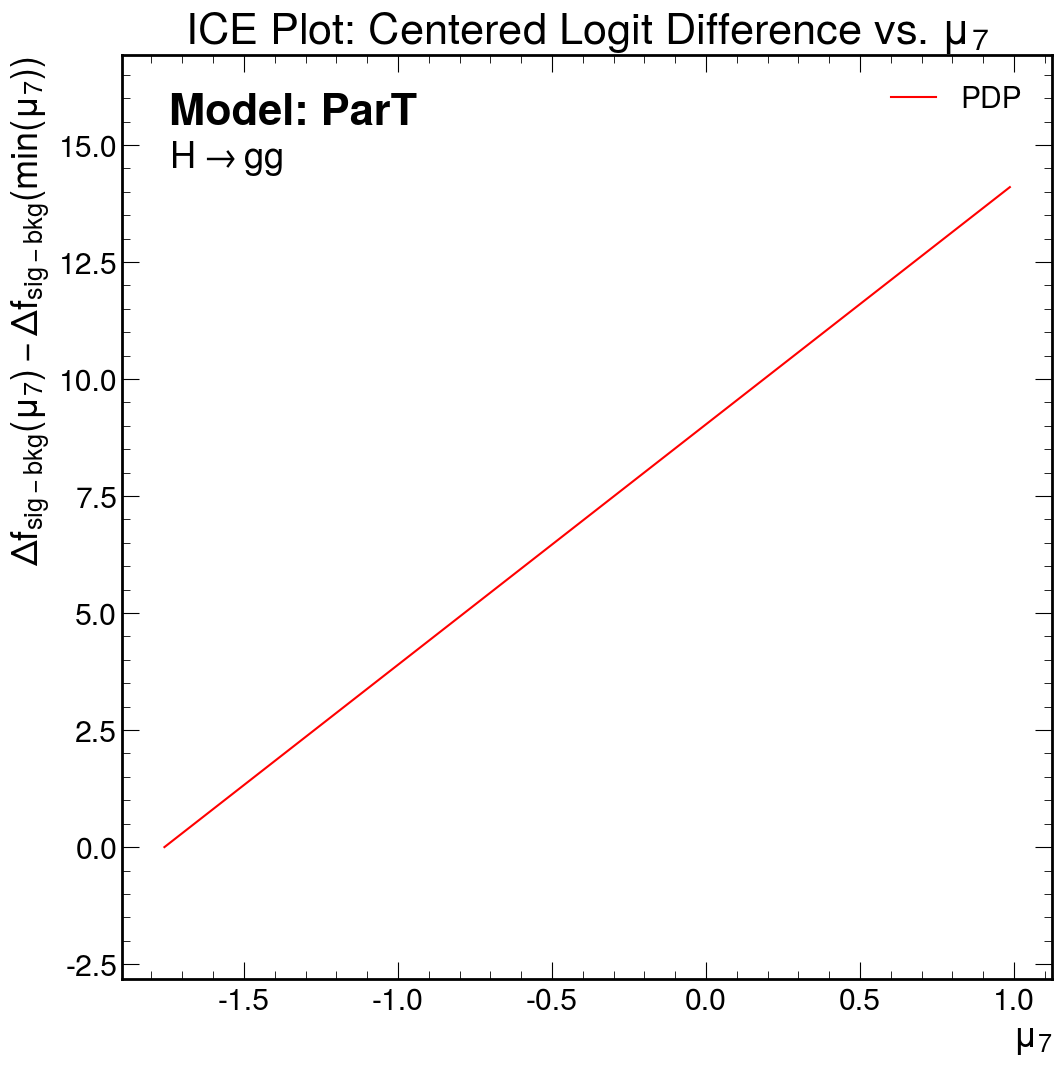

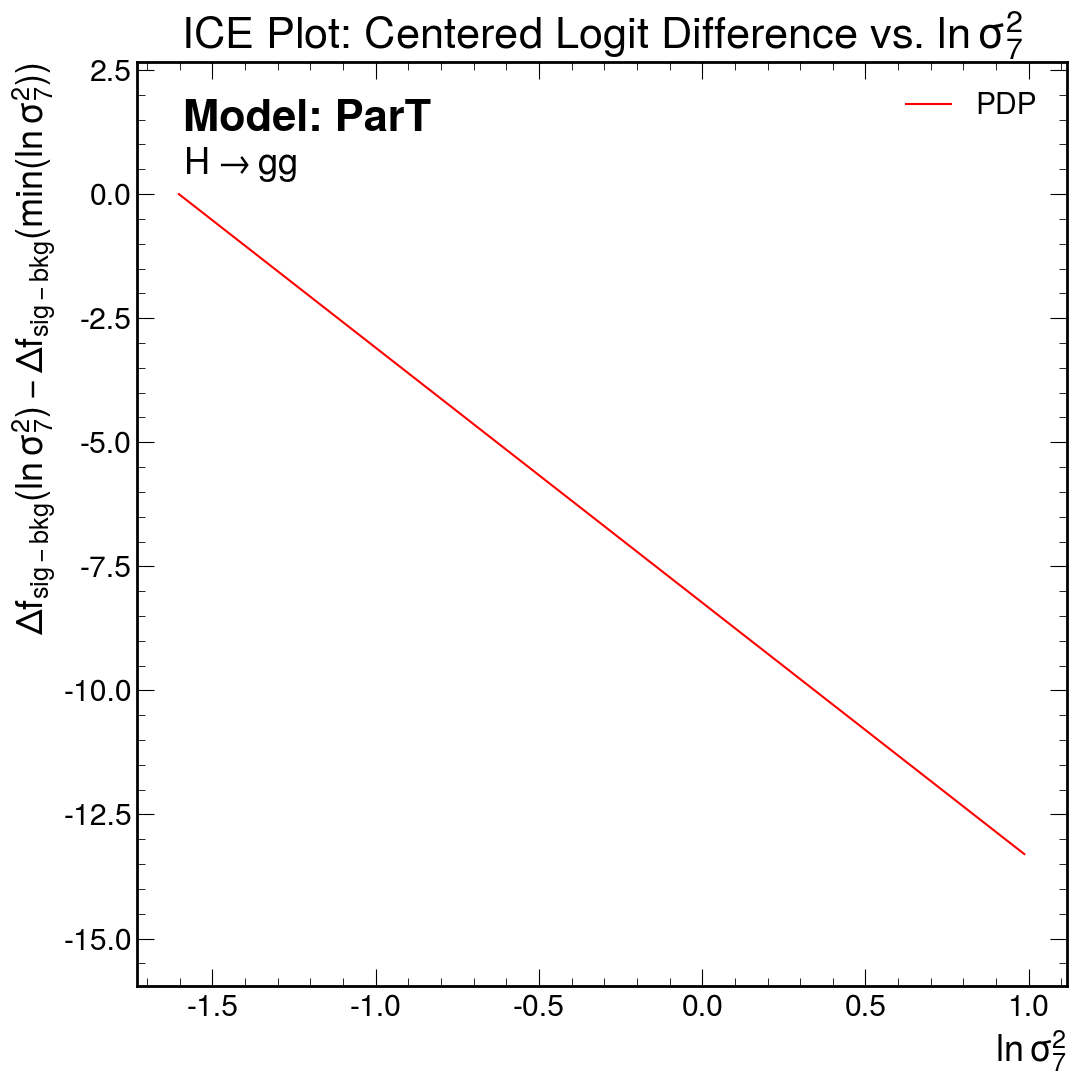

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/HToGG/Surrogate/Surrogate_E1-SURROGATES_ResNet-S_BVAE/checkpoint.pkl...


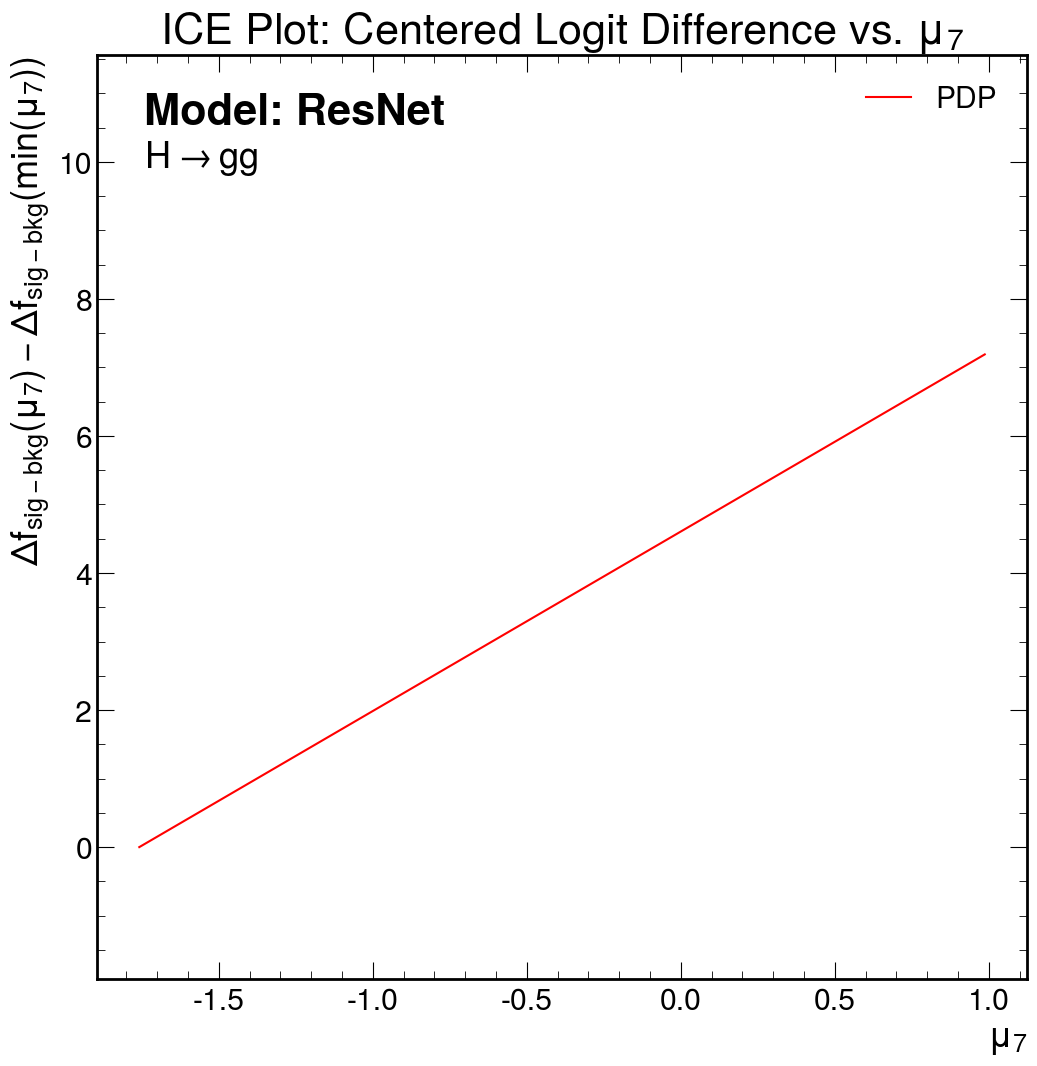

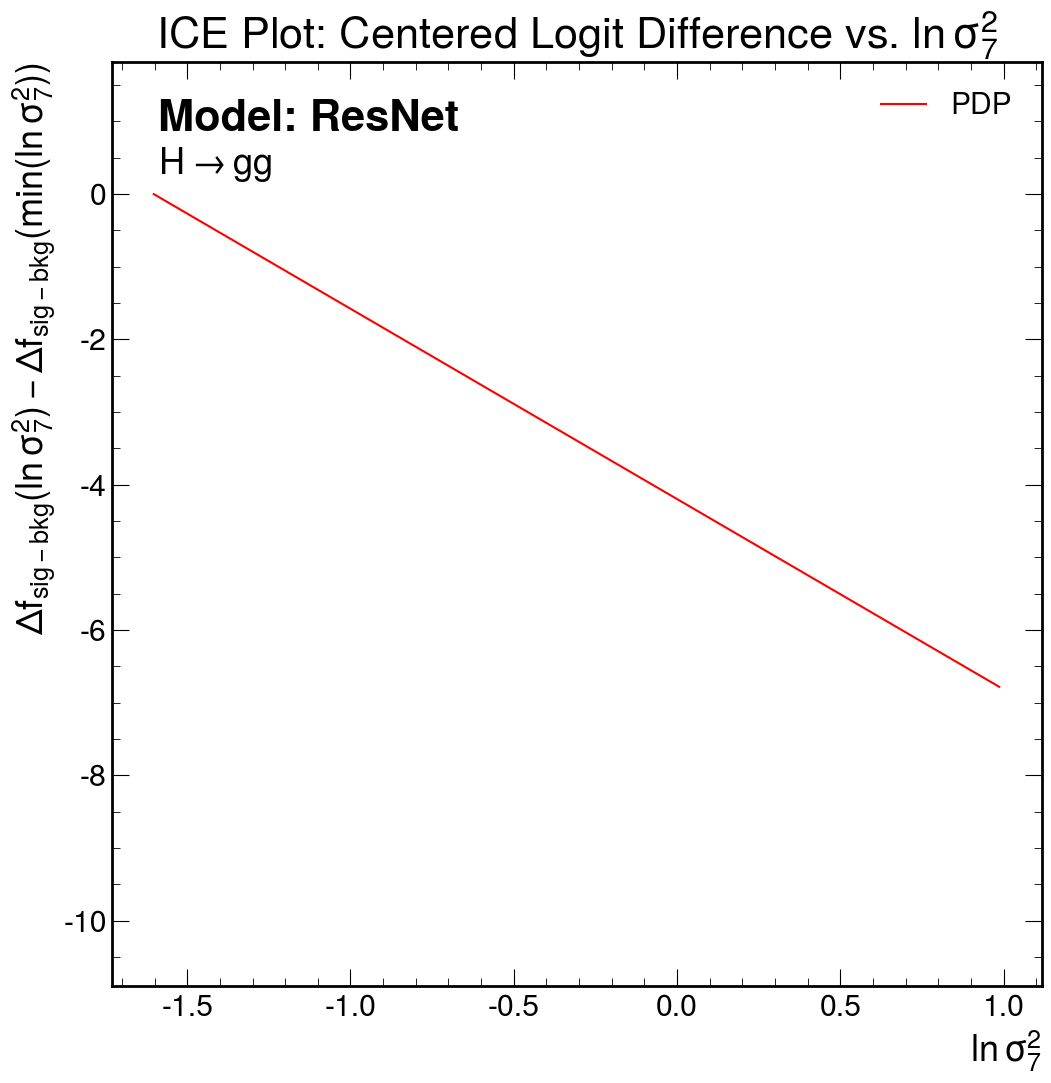

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/HToGG/Surrogate/Surrogate_E1-SURROGATES_ParticleNet-S_BVAE/checkpoint.pkl...


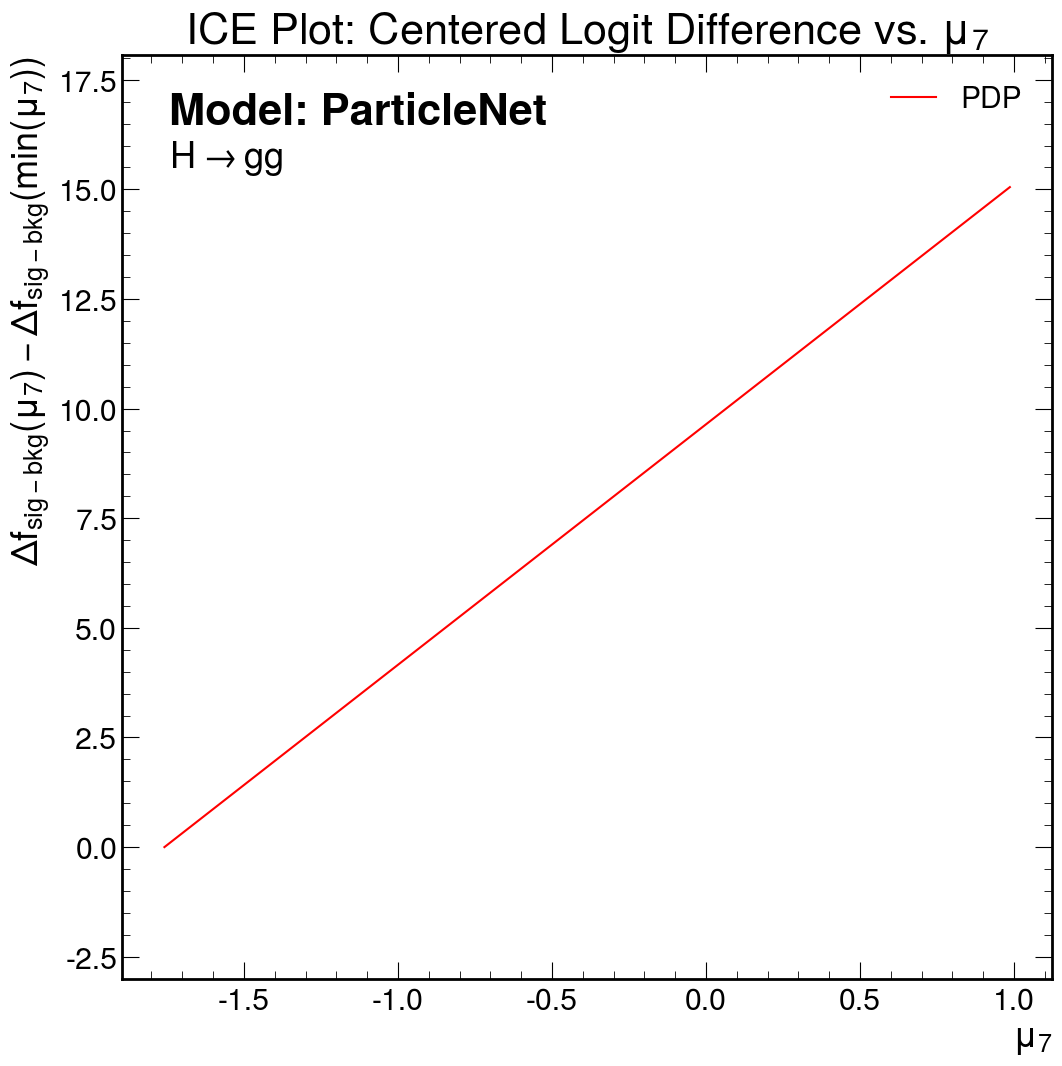

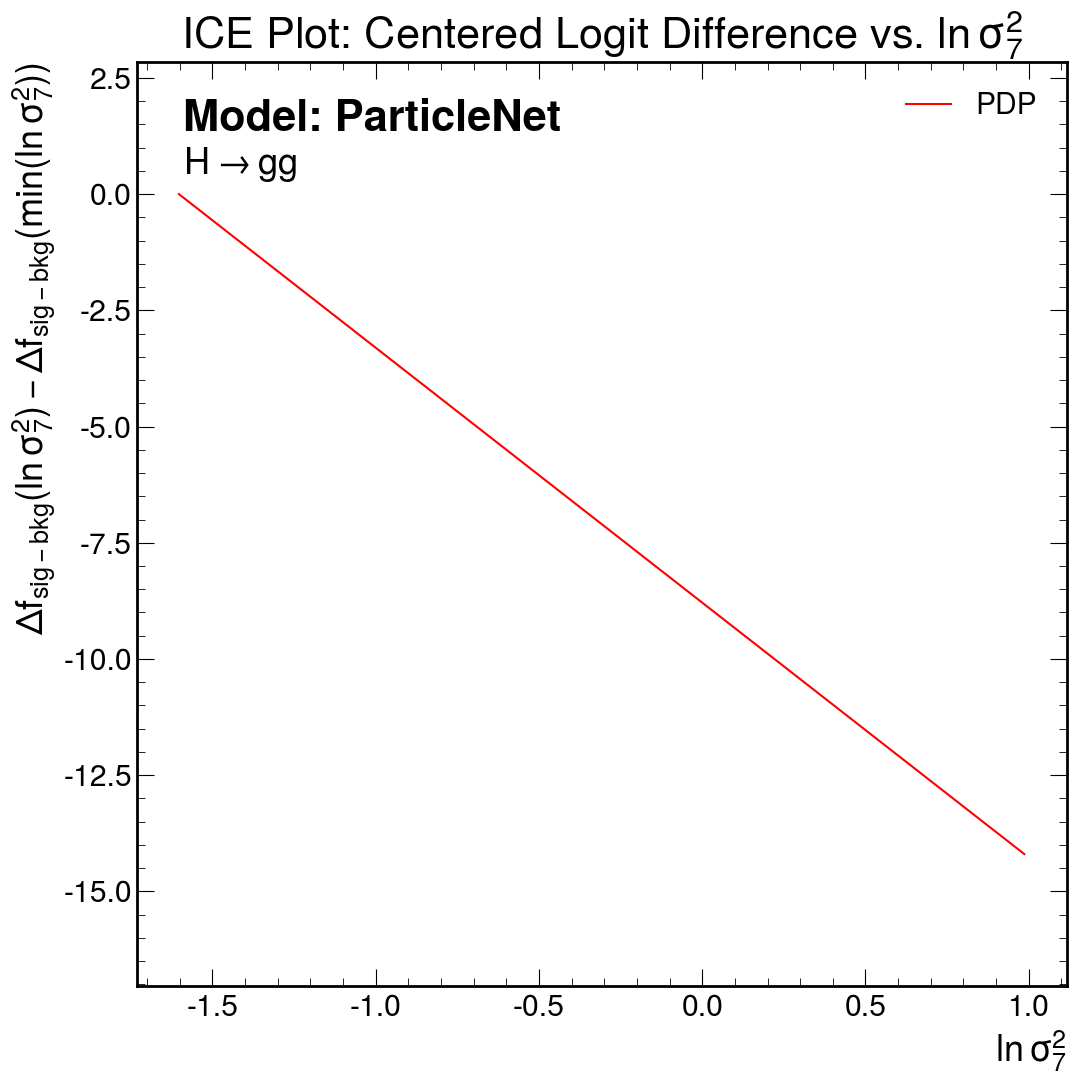

In [51]:
counts_lookup = {
    'TTBar': [4, 7, 1],
    'WToQQ': [7, 3, 2],
    'HToGG': [7, 5, 0]
}

def ice_handler(suite, var_indices, event):

    vae_preds = suite.vae_outputs['preds']
    mu_vals = vae_preds['mu'].array().to_numpy()
    logvar_vals = vae_preds['log_var'].array().to_numpy()
    latents = torch.Tensor(np.concatenate([mu_vals, logvar_vals], axis=1))
    labels = torch.Tensor(suite.vae_outputs['inputs']['label'].array().to_numpy())
    
    regressor = PySRRegressor.from_file(run_directory = suite.surrogate_folder)
    torch_init = regressor.pytorch()
    model = torch_init if not isinstance(torch_init, list) else torch_init[0]
    eq = regressor.latex()

    eqv = EquationVisualizer(model, latents, labels)

    idx = var_indices[0]
    mu_idx = idx
    var_idx = idx + 8

    mu_data_points = eqv.ice(mu_idx, 50, order=0, event=event)[f'dim_{mu_idx}_order_{0}'][event]
    mu_x = mu_data_points['x']
    mu_y = np.array(mu_data_points['y'])
    plot_ice(mu_x, mu_y, suite.model_name, suite.signal, idx, eq, 'mu')

    var_data_points = eqv.ice(var_idx, 50, order=0, event=event)[f'dim_{var_idx}_order_{0}'][event]
    var_x = var_data_points['x']
    var_y = np.array(var_data_points['y'])
    plot_ice(var_x, var_y, suite.model_name, suite.signal, idx, eq, 'lnvar')

for signal in signals:
    print(f'Working on {signal}')
    for model_name in models:
        suite = TestSuite(signal, model_name)
        ice_handler(suite, counts_lookup[signal], event='none')

In [68]:
from sklearn.metrics import r2_score, root_mean_squared_error

for signal in signals:
    print(f'Working on {signal}')
    suite = TestSuite(signal, model_name)
    regressor = PySRRegressor.from_file(run_directory = suite.obs_folder)

    mu_vals = suite.vae_outputs['preds']['mu'].array().to_numpy()
    obs_vals = suite.obs_outputs['preds']['mu_vals'].array().to_numpy().reshape(400000, 8)

    print(f'Observable LaTeX equations for {signal}')
    latex = regressor.latex()

    for eq in latex:
        print(eq)
    
    print('\r')

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/TTBar/Observables/Observables_E2-OBSERVABLES_BVAE/checkpoint.pkl...


Working on TTBar
Observable LaTeX equations for TTBar


Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Observables/Observables_E2-OBSERVABLES_BVAE/checkpoint.pkl...


6.87 \sqrt{jet_{tau3}} - 1.43
\frac{jet_{tau2}}{-0.248}
10.1 EFP_{29} \log{\left(EFP_{7} \right)} + 0.678
jet_{energy}^{-0.221}
0.737 + jet_{tau1} \left(-4.92\right)
EFP_{29} + \sqrt{\left({0.860}^{jet_{energy}}\right)^{EFP_{34}}}
\log{\left(- 0.371 \log{\left(EFP_{3} \right)} \right)}
EFP_{7} \cdot 11.1 - 0.495

Working on WToQQ
Observable LaTeX equations for WToQQ


Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/HToGG/Observables/Observables_E2-OBSERVABLES_BVAE/checkpoint.pkl...


\frac{jet_{pt}}{\left(EFP_{21} + 0.216\right) \left(jet_{energy} + 329.\right)} - 2.04
\log{\left(jet_{nparticles} \right)} - 3.28
0.862 - \frac{2.04 \cdot 10^{6}}{{1.45}^{jet_{nparticles}} + 1.56 \cdot 10^{6}}
1.37 - \frac{6.53}{\frac{1}{EFP_{17}} EFP_{22}}
\frac{-1.00 + \frac{10.5}{3.92 + \frac{e^{\frac{jet_{energy}}{202.}}}{10.5 \frac{jet_{energy}}{jet_{pt}}}}}{{0.925}^{jet_{nparticles}} + 0.925}
\frac{\log{\left(2.58 {0.996}^{jet_{energy}} \sqrt{jet_{energy} \left({0.997}^{jet_{pt}} + EFP_{5}\right)} + 0.398 \right)}}{EFP_{5}^{jet_{tau4}} + \left({0.988}^{jet_{energy}} + 0.996\right)^{jet_{energy}}}
\log{\left(\frac{EFP_{11}}{EFP_{18}^{0.865}} \right)}
\frac{- 0.452 jet_{tau1} - 0.452 \left(-0.373 + \frac{jet_{sdmass}}{jet_{energy}}\right) \left(\sqrt{jet_{tau2}} + 0.0899\right)}{EFP_{21} + 0.0308}

Working on HToGG
Observable LaTeX equations for HToGG
\left({0.924}^{jet_{energy}}\right)^{EFP_{8}} - 0.399
\log{\left(\frac{2.37 jet_{pt}}{jet_{energy}} \right)} - \frac{2.92 EFP_{33}}

In [54]:
suite = TestSuite('TTBar', 'ParT')
obs_vals = suite.obs_outputs['preds']['mu_vals'].array().to_numpy()

In [41]:
def mu_hists(suite, indices: list):

    mu_vals = suite.vae_outputs['preds']['mu'].array().to_numpy()
    labels = suite.vae_outputs['inputs']['label'].array().to_numpy()

    for idx in indices:
        sig_mu = mu_vals[:, idx][labels==1]
        bkg_mu = mu_vals[:, idx][labels==0]

        fig, ax = plt.subplots(figsize=(12, 12))

        ax.hist(bkg_mu, bins = 100, alpha=0.7, label = 'Background', rasterized=True)
        ax.hist(sig_mu, bins = 100, alpha=0.7, label = 'Signal', rasterized=True)
        ax.legend()
        ax.set_title(rf'$\mu_{idx}$ Distributions for $W \rightarrow qq$')
        ax.set_xlabel(rf'$\mu_{idx}$')
        ax.set_ylabel('Counts')
        
        fig_prefix = f'{figure_dir}/{suite.signal}'

        plt.show()
        
        fig.savefig(f'{fig_prefix}_muhist_mu_{idx}.pdf', dpi=150, format='pdf')
        plt.close(fig)

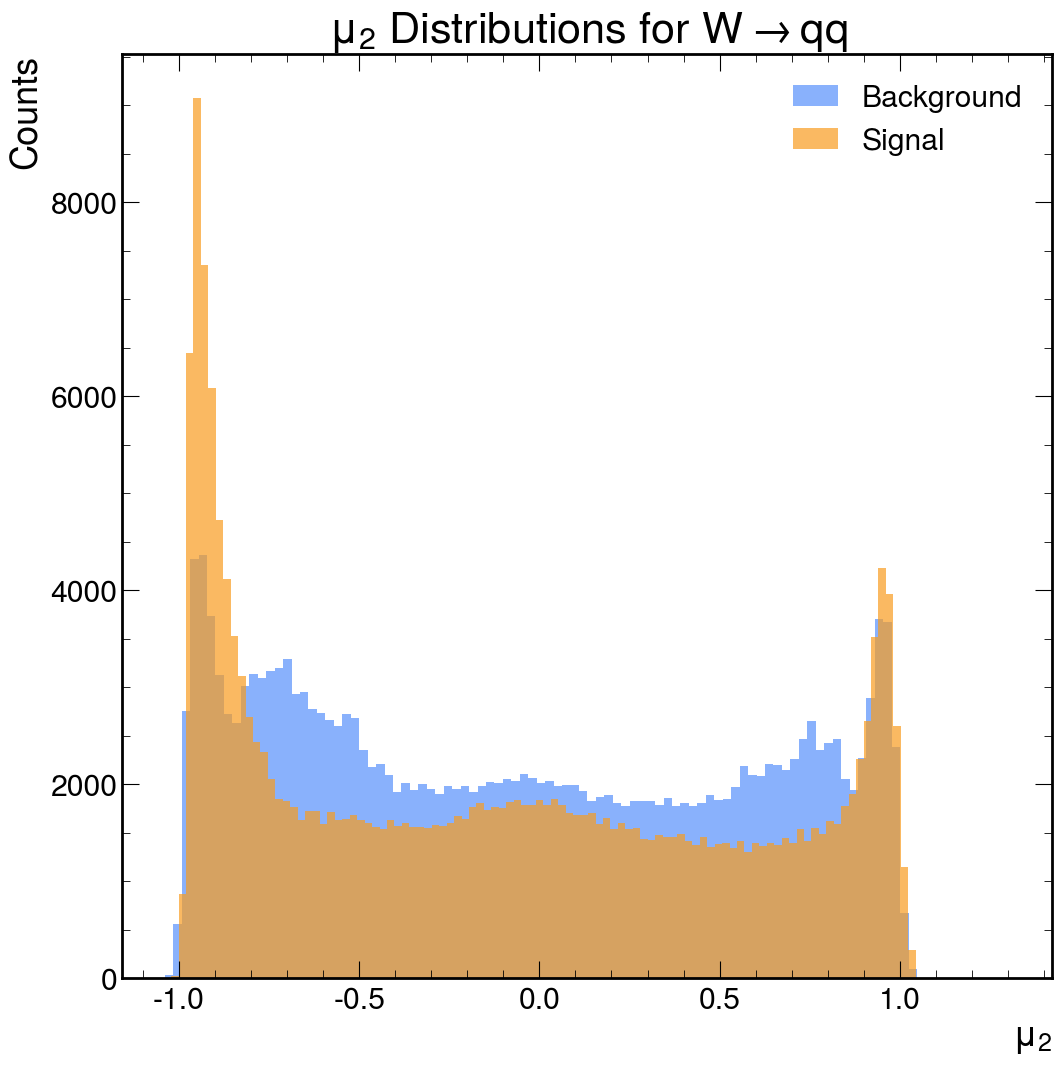

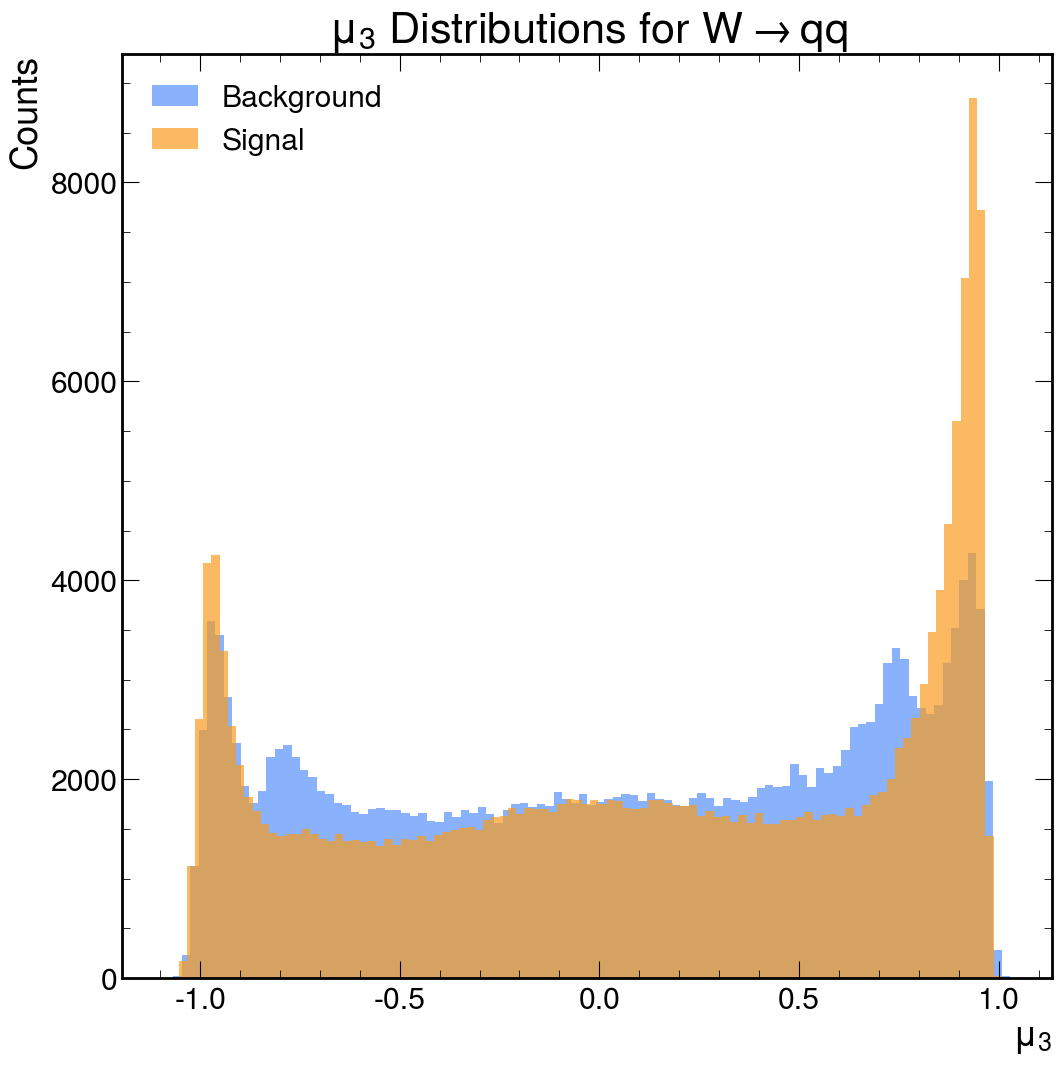

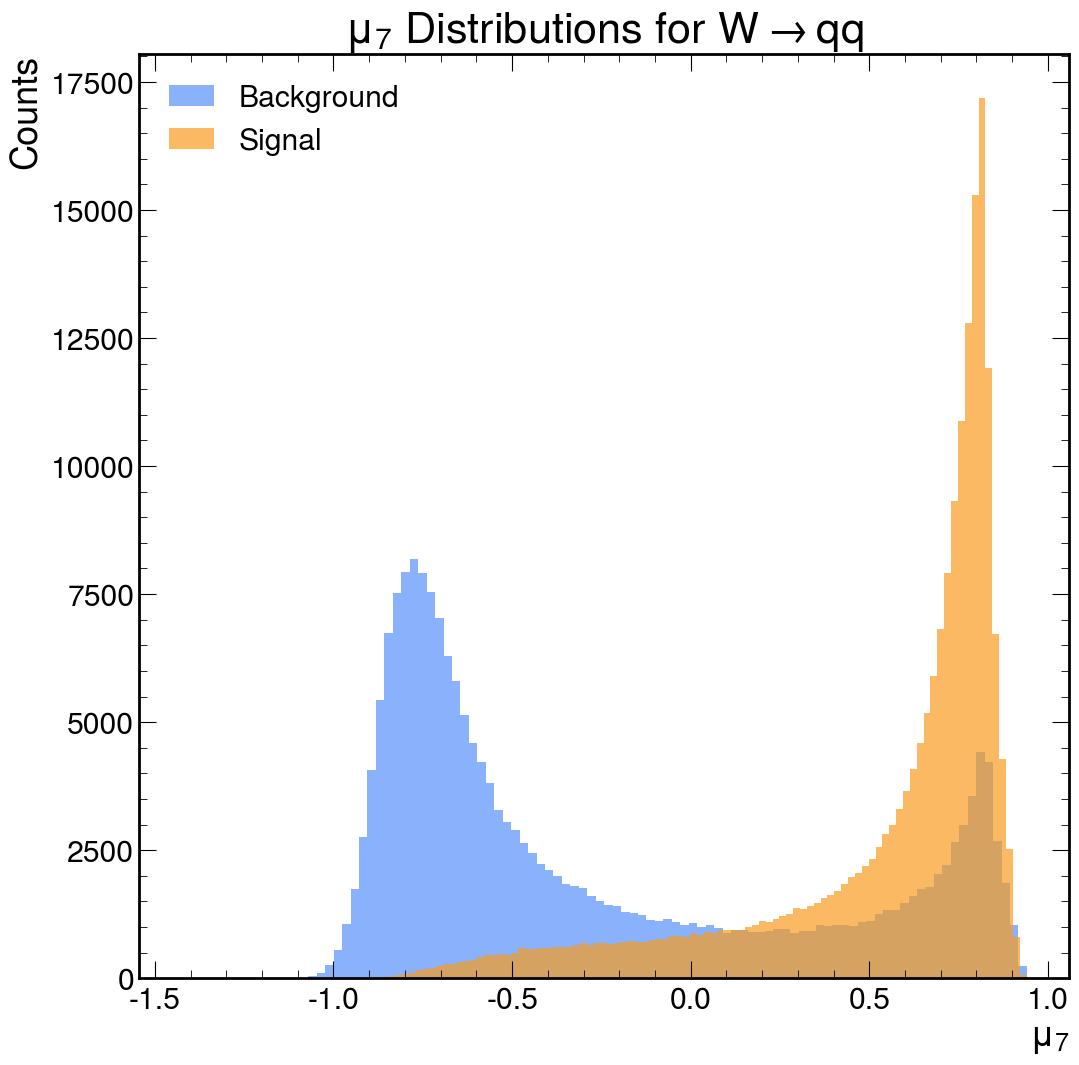

In [42]:
suite = TestSuite('HToGG', 'ParT')

indices = [2, 3, 7]

mu_hists(suite, indices)

In [13]:
def multiple_ices(suite, dim_idx, event):

    vae_preds = suite.vae_outputs['preds']
    mu_vals = vae_preds['mu'].array().to_numpy()
    logvar_vals = vae_preds['log_var'].array().to_numpy()
    latents = torch.Tensor(np.concatenate([mu_vals, logvar_vals], axis=1))
    labels = torch.Tensor(suite.vae_outputs['inputs']['label'].array().to_numpy())
    
    regressor = PySRRegressor.from_file(run_directory = suite.surrogate_folder)
    torch_init = regressor.pytorch()
    model = torch_init if not isinstance(torch_init, list) else torch_init[0]
    eq = regressor.latex()

    eqv = EquationVisualizer(model, latents, labels)

    mu_idx = dim_idx
    var_idx = dim_idx + 8

    mu_data_points = eqv.ice(mu_idx, 50, order=0, event=event)[f'dim_{mu_idx}_order_{0}'][event]
    mu_x = mu_data_points['x']
    mu_y = np.array(mu_data_points['y'])

    var_data_points = eqv.ice(var_idx, 50, order=0, event=event)[f'dim_{var_idx}_order_{0}'][event]
    var_x = var_data_points['x']
    var_y = np.array(var_data_points['y'])

    _model_outputs[suite.signal][suite.model_name][f'mu{mu_idx}_x'] = mu_x
    _model_outputs[suite.signal][suite.model_name][f'mu{mu_idx}_y'] = mu_y
    _model_outputs[suite.signal][suite.model_name][f'lnvar{mu_idx}_x'] = var_x
    _model_outputs[suite.signal][suite.model_name][f'lnvar{mu_idx}_y'] = var_y

In [24]:
import matplotlib.colors as mcolors

def multiple_ice_mu(model_names, signal, dim, var):
    signal_lookup = {
        'TTBar': r'$t\rightarrow bqq$',
        'WToQQ': r'$W\rightarrow qq$',
        'HToGG': r'$H\rightarrow gg$'
    }

    var_lookup = {
        'lnvar': r'\ln \sigma^2',
        'mu': r'\mu'
    }

    fig, ax = plt.subplots(figsize=(12, 12))

    fig_prefix = f'{figure_dir}/{signal}'
    dirname = os.path.dirname(fig_prefix)
    if dirname and not os.path.exists(dirname):
        os.makedirs(dirname)

    for model_name in model_names:
    
        signal_str = signal_lookup[signal]

        x = _model_outputs[signal][model_name][f'{var}{dim}_x']
        y = _model_outputs[signal][model_name][f'{var}{dim}_y']
    
        y_vals = y.T
        centered_lines = y_vals - np.expand_dims(y_vals[:, 0], axis=1)
    
        x_2d = np.tile(x, (centered_lines.shape[0], 1))
        segments = np.stack([x_2d, centered_lines], axis=-1)
        
        pdp_line = np.mean(y, axis=1)
        pdp_line_centered = np.mean(centered_lines.T, axis=1)
        
        #line_segments = LineCollection(segments, colors='k', alpha=0.001, linewidth=0.1, antialiased=False)
        #ax.add_collection(line_segments)
        
        ax.plot(x, pdp_line_centered, label=model_name, linewidth=2.5)
    ax.set_title(rf'PDP: Centered Logit Difference vs. ${var_lookup[var]}_{{{dim}}}$')
    ax.set_xlabel(rf'${var_lookup[var]}_{{{dim}}}$')
    ax.set_ylabel(rf'$\Delta f_{{sig-bkg}}({var_lookup[var]}_{{{dim}}}) - \Delta f_{{sig-bkg}}(\min({var_lookup[var]}_{{{dim}}}))$')
    ax.margins(y=0.2)
    
    ax.text(0.05, 0.96, s=signal_str, transform=ax.transAxes, va='top', ha='left', fontweight='bold')
    
    ax.legend()
    plt.show()
    fig.savefig(f'{fig_prefix}_ICEPDP_{var}_{dim}.pdf', dpi=150, format='pdf')
    plt.close(fig)

Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ParT-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ResNet-S_BVAE/checkpoint.pkl...
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/WToQQ/Surrogate/Surrogate_E1-SURROGATES_ParticleNet-S_BVAE/checkpoint.pkl...


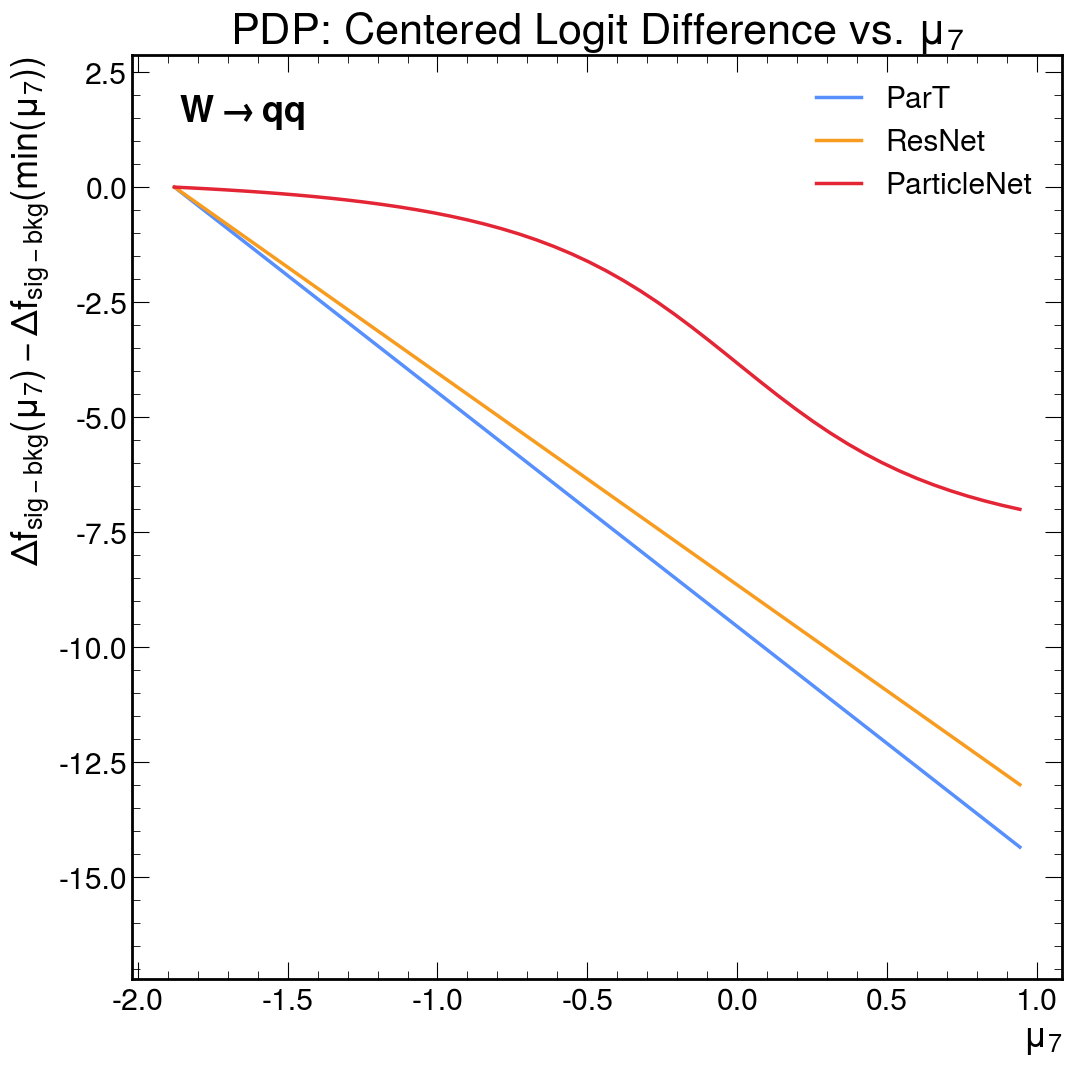

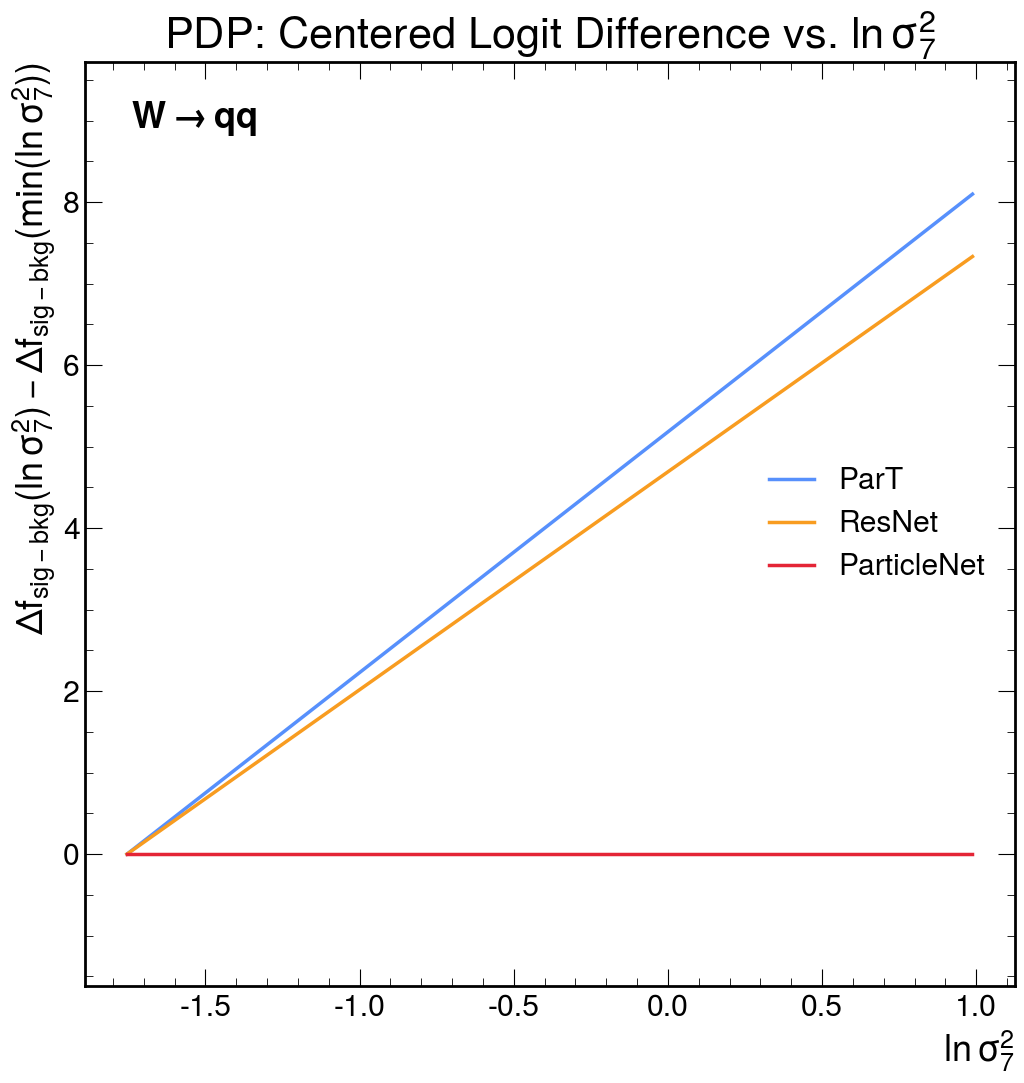

In [25]:
plt.style.use([mh.style.ROOT, 'fast'])

_model_outputs = {}
for signal in signals:
    _model_outputs[signal] = {}
    for model_name in models:
        _model_outputs[signal][model_name] = {}

signal = 'WToQQ'

for model_name in models:
    suite = TestSuite(signal, model_name)
    for idx in [7]:
        multiple_ices(suite, idx, event='none')

for dim in [7]:
    multiple_ice_mu(models, signal, dim, 'mu')
    multiple_ice_mu(models, signal, dim, 'lnvar')

In [35]:
def construct_observables(
    vae_outputs,
    dmax=4,
    beta=1.0,
    approximable=[],
):
    
    input_dict = vae_outputs['inputs']
    mu = vae_outputs['preds']['mu'].array().to_numpy()
    
    jet_features = {}
    feature_names = []

    observer_names = [
        'jet_pt',
        'jet_eta',
        'jet_phi',
        'jet_energy',
        'jet_nparticles',
        'jet_sdmass',
        'jet_tau1',
        'jet_tau2',
        'jet_tau3',
        'jet_tau4'
    ]

    for name in observer_names:
        jet_features[name] = input_dict[name].array().to_numpy()
        feature_names.append(name)

    part_px = input_dict['part_px'].array().to_numpy()
    part_py = input_dict['part_py'].array().to_numpy()
    part_pz = input_dict['part_pz'].array().to_numpy()
    part_pt = np.hypot(part_px, part_py)
    part_e = input_dict['part_energy'].array().to_numpy()
    part_deta = input_dict['part_deta'].array().to_numpy()
    part_dphi = input_dict['part_dphi'].array().to_numpy()
    
    def wrap_phi(phi):
        return (phi + np.pi) % (2 * np.pi) - np.pi
    
    part_eta = part_deta + input_dict['jet_eta'].array().to_numpy()[:, None]
    part_phi = wrap_phi(part_dphi + input_dict['jet_phi'].array().to_numpy()[:, None])
    
    part_m2 = part_e**2 - (part_px**2 + part_py**2 + part_pz**2)
    part_m = np.sqrt(np.maximum(part_m2, 0))

    hadr_package = [
        part_pt,
        part_eta,
        part_phi,
        part_m
    ]

    ptetaphim = np.concatenate([np.expand_dims(k, axis=1) for k in hadr_package], axis=1)
    hadr_coords = np.transpose(ptetaphim, (0, 2, 1))
    
    EFP = energyflow.EFPSet(('d<=', dmax), measure='hadr', beta=beta)

    _logger.info(f'EFP Specs: \r{EFP.specs}')
    _logger.info(f'EFP graphs: \r{EFP.graphs()}')
    efps = EFP.batch_compute(hadr_coords)
    
    observables = []

    for key, value in jet_features.items():
        if key in approximable:
            continue
        observables.append(value)

    if 'jet_mass' not in approximable:
        jet_m = np.sum(part_m, axis=-1, keepdims=False)
        observables.append(jet_m)
        feature_names.append('jet_mass')

    observables.extend(efps.T)
    feature_names = [name for name in feature_names if name not in approximable]
    
    for i in range(len(efps.T)):
        feature_names.append(f'EFP_{i}')

    defined_observables = np.array(observables).transpose((-1, 0))
    latents = mu
    
    return defined_observables, latents, feature_names

In [39]:
suite = TestSuite('HToGG', 'ParT')


defined_observables, latents, feature_names = construct_observables(
    suite.vae_outputs
)

ValueError: computed checksum 10879191126286874121 didn't match expected checksum 16249934399827250638
in file /home/alang/ppCodes/part_gp/outputs/metrics/HToGG/ParT_E3-EVAL_BVAE/ParT_BVAE_outputs.root